In [31]:
# import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy as np

import btrack
# from btrack import datasets

from skimage.io import imread
from skimage.util import montage
from skimage.transform import resize

# from matplotlib.animation import FuncAnimation
from IPython.display import HTML


from tifffile import imread
from tifffile import imwrite

import time
import json
import pickle



import importlib
import ablation_driver
importlib.reload(ablation_driver)

from ablation_driver import save_objects_pkl, run_sweep
# from helper import plot_track_montage

In [3]:
print(btrack.__version__)

0.6.5


In [2]:
segments = '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments'
props = '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/regionprops'

In [3]:
# CONFIG_FILE = "trackconfig.json"

# basepath = '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging'

# segments_list = [
# # "01_hybrid_C4.npy",
# # "01_siPRRX1_B3.npy",
# # "02_control_D2.npy",
# # "02_mmMYOD1_D3.npy",
# # "test.npy",
# "01_control_C2.npy",
# # "01_hybrid_C6.npy",
# # "01_siPRRX1_B4.npy",
# # "02_mmMYOD1_D4.npy",
# # "01_control_D2.npy",
# # "01_mmMYOD1_D3.npy",
# # "02_hybrid_C4.npy",
# # "02_siPRRX1_B3.npy",
# # "01_mmMYOD1_D4.npy",
# # "02_control_C2.npy",
# # "02_hybrid_C6.npy",
# # "02_siPRRX1_B4.npy",
# ]

# full_segments_list = [f'{basepath}/segments/{i}' for i in segments_list]
# print(full_segments_list)

['/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_control_C2.npy']


In [4]:
# control_segments = f'{segments}/01_control_B2.npy'
# # props = f'{segments}/01_control_B2_props.npy'


# control_name = '01_control_B2'
# control_segments_data = np.load(control_segments)
# print(control_segments_data.shape)

(67, 2618, 3026)


In [7]:
# segment_path = f'{segments}/test.npy'
# # img_path = 


# FEATURES = [
#     "area", 
#     "major_axis_length", 
#     "minor_axis_length", 
#     "orientation", 
#     "solidity",
#     "eccentricity"
# ]

# segmentation = np.load(segment_path)
# print(segmentation.shape)

# objects = btrack.utils.segmentation_to_objects(
#         segments_data, 
#         properties=tuple(FEATURES), 
#         # num_workers=16,  # parallelise this
#     )


# # initialise a tracker session using a context manager
# with btrack.BayesianTracker() as tracker:

#     # configure the tracker using a config file
#     tracker.configure(CONFIG_FILE)
#     tracker.max_search_radius = 50
#     tracker.tracking_updates = ["MOTION", "VISUAL"]
#     tracker.features = FEATURES

#     # append the objects to be tracked
#     tracker.append(objects)

#     # set the tracking volume
#     tracker.volume=((0, 1600), (0, 1200))

#     # track them (in interactive mode)
#     tracker.track(step_size=100)

#     # generate hypotheses and run the global optimizer
#     tracker.optimize()

#     # get the tracks in a format for napari visualization
#     data, properties, graph = tracker.to_napari()

#     # store the tracks
#     tracks = tracker.tracks

#     # store the configuration
#     cfg = tracker.configuration


#     # export the track data 
#     tracker.export(f"tracks/{name}.h5", obj_type="obj_type_1")

(67, 2618, 3026)


In [ ]:
# def full_tracking_pipeline(name, segment_path):
#     FEATURES = [
#         "area", 
#         "major_axis_length", 
#         "minor_axis_length", 
#         "orientation", 
#         "solidity",
#         "eccentricity"
#     ]
    
#     segments_data = np.load(segment_path)
    
#     objects = btrack.utils.segmentation_to_objects(
#         segments_data, 
#         properties=tuple(FEATURES), 
#         num_workers=16,  # parallelise this
#     )
#     # Code directly from Btrack documentation
    
    
#     # initialise a tracker session using a context manager
#     with btrack.BayesianTracker() as tracker:
    
#         # configure the tracker using a config file
#         tracker.configure(CONFIG_FILE)
#         tracker.max_search_radius = 50
#         tracker.tracking_updates = ["MOTION", "VISUAL"]
#         tracker.features = FEATURES
    
#         # append the objects to be tracked
#         tracker.append(objects)
    
#         # set the tracking volume
#         tracker.volume=((0, 1600), (0, 1200))
    
#         # track them (in interactive mode)
#         tracker.track(step_size=100)
    
#         # generate hypotheses and run the global optimizer
#         tracker.optimize()
    
#         # get the tracks in a format for napari visualization
#         data, properties, graph = tracker.to_napari()
        
#         # store the tracks
#         tracks = tracker.tracks
        
#         # store the configuration
#         cfg = tracker.configuration
    
    
#         # export the track data 
#         tracker.export(f"tracks/{name}.h5", obj_type="obj_type_1")

In [3]:
%%time

CONFIG_FILE = "cell_config.json"

control_name1 = '01_control_C2'
control_segments1 = f'{segments}/{control_name1}.npy'
control_segments_data1 = np.load(control_segments1)

print(f'{control_name1} segments shape = {control_segments_data1.shape}')

01_control_C2 segments shape = (67, 2621, 3026)
CPU times: user 9.89 ms, sys: 1.02 s, total: 1.03 s
Wall time: 7min 46s


In [26]:
xs = np.array([o.x for o in control_objects1])
ys = np.array([o.y for o in control_objects1])
print("x range:", xs.min(), xs.max())
print("y range:", ys.min(), ys.max())
print("segmentation array shape:", control_segments_data1.shape)

x range: 2.3137254901960786 3023.904761904762
y range: 2.3962264150943398 2618.75
segmentation array shape: (67, 2621, 3026)


In [4]:
%%time

FEATURES = [
    "area", 
    "axis_major_length",
    "axis_minor_length",
    "orientation", 
    "solidity",
    "eccentricity"
]

control_objects1 = btrack.utils.segmentation_to_objects(
    control_segments_data1, 
    properties=tuple(FEATURES), 
    num_workers=8,  # parallelise this
)

[INFO][2026/07/27 03:42:23 PM] Localizing objects from segmentation...
[INFO][2026/07/27 03:42:23 PM] Processing using 8 workers.
100%|██████████| 67/67 [00:07<00:00,  8.60it/s]
[INFO][2026/07/27 03:42:31 PM] Objects are of type: <class 'dict'>
[INFO][2026/07/27 03:42:31 PM] ...Found 39967 objects in 67 frames.


CPU times: user 2.23 s, sys: 3.77 s, total: 6 s
Wall time: 8.44 s


In [14]:
%%time
save_objects_pkl(control_objects1, "control_objects1.pkl")#, feature_names=FEATURES)
    
results = run_sweep(
    config_path=CONFIG_FILE,
    vol_x=1600, vol_y=1200,
    objects_pkl_path="control_objects1.pkl",
    n_frames=15,
    sweeps={
        "MotionModel.accuracy": [1.0, 2.0, 7.5, 15.0, 30.0, 50.0],
        "MotionModel.dt": [0.1, 0.5, 1.0, 2.0, 5.0],
        "MotionModel.max_lost": [2, 5, 10, 20],
    },
)
pd.DataFrame(results)

Baseline (unmodified config):
  baseline=None -> n_tracks=5560 mean_len=1.58 median_len=1.0 frac_len1=95.41%

MotionModel.accuracy sweep:
  MotionModel.accuracy=1.0 -> n_tracks=8760 mean_len=1.00 median_len=1.0 frac_len1=100.00%
  MotionModel.accuracy=2.0 -> n_tracks=5597 mean_len=1.57 median_len=1.0 frac_len1=95.12%
  MotionModel.accuracy=7.5 -> n_tracks=5560 mean_len=1.58 median_len=1.0 frac_len1=95.41%
  CRASHED (exit -6): MotionModel.accuracy=15.0
   stderr tail: MOTION']
python3.11: ./btrack/include/eigen/Eigen/src/Core/Block.h:147: Eigen::Block<XprType, BlockRows, BlockCols, InnerPanel>::Block(XprType&, Eigen::Index, Eigen::Index, Eigen::Index, Eigen::Index) [with XprType = Eigen::Matrix<double, -1, 1>; int BlockRows = -1; int BlockCols = 1; bool InnerPanel = false; Eigen::Index = long int]: Assertion `startRow >= 0 && blockRows >= 0 && startRow <= xpr.rows() - blockRows && startCol >= 0 && blockCols >= 0 && startCol <= xpr.cols() - blockCols' failed.

  CRASHED (exit -6): Motion

,param,value,n_tracks,mean_len,median_len,frac_len1,status,returncode
0,baseline,None,5560.0,1.577158,1.0,0.954137,ok,NaN
1,MotionModel.accuracy,1.0,8760.0,1.000000,1.0,1.000000,ok,NaN
2,MotionModel.accuracy,2.0,5597.0,1.565124,1.0,0.951224,ok,NaN
3,MotionModel.accuracy,7.5,5560.0,1.577158,1.0,0.954137,ok,NaN
4,MotionModel.accuracy,15.0,NaN,NaN,NaN,NaN,crashed,-6.0
5,MotionModel.accuracy,30.0,NaN,NaN,NaN,NaN,crashed,-6.0
6,MotionModel.accuracy,50.0,NaN,NaN,NaN,NaN,crashed,-6.0
7,MotionModel.dt,0.1,5560.0,1.577158,1.0,0.954137,ok,NaN
8,MotionModel.dt,0.5,5560.0,1.577158,1.0,0.954137,ok,NaN
9,MotionModel.dt,1.0,5560.0,1.577158,1.0,0.954137,ok,NaN


In [16]:
static_A = [1,0,0,0,0,0,
            0,1,0,0,0,0,
            0,0,1,0,0,0,
            0,0,0,1,0,0,
            0,0,0,0,1,0,
            0,0,0,0,0,1]  # identity: predicted position = previous position, no velocity carry-over

results2 = run_sweep(
    config_path=CONFIG_FILE,
    vol_x=1600, vol_y=1200,
    objects_pkl_path="control_objects1.pkl",
    n_frames=15,
    sweeps={
        "MotionModel.A.matrix": [static_A],
        "MotionModel.accuracy": [2.0, 7.5],  # re-run these WITH static A for comparison
    },
)
pd.DataFrame(results2)

Baseline (unmodified config):
  baseline=None -> n_tracks=5560 mean_len=1.58 median_len=1.0 frac_len1=95.41%

MotionModel.A.matrix sweep:
  MotionModel.A.matrix=[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1] -> n_tracks=5555 mean_len=1.58 median_len=1.0 frac_len1=95.46%

MotionModel.accuracy sweep:
  MotionModel.accuracy=2.0 -> n_tracks=5597 mean_len=1.57 median_len=1.0 frac_len1=95.12%
  MotionModel.accuracy=7.5 -> n_tracks=5560 mean_len=1.58 median_len=1.0 frac_len1=95.41%


,param,value,n_tracks,mean_len,median_len,frac_len1,status
0,baseline,null,5560,1.577158,1.0,0.954137,ok
1,MotionModel.A.matrix,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, ...",5555,1.581818,1.0,0.954635,ok
2,MotionModel.accuracy,2.0,5597,1.565124,1.0,0.951224,ok
3,MotionModel.accuracy,7.5,5560,1.577158,1.0,0.954137,ok


In [18]:
results3 = run_sweep(
    config_path=CONFIG_FILE,
    vol_x=1600, vol_y=1200,
    objects_pkl_path="control_objects1.pkl",
    n_frames=15,
    sweeps={
        "MotionModel.prob_not_assign": [0.01, 0.3, 0.6, 0.9, 0.99],
    },
)
pd.DataFrame(results3)

Baseline (unmodified config):
  baseline=None -> n_tracks=5560 mean_len=1.58 median_len=1.0 frac_len1=95.41%

MotionModel.prob_not_assign sweep:
  MotionModel.prob_not_assign=0.01 -> n_tracks=5560 mean_len=1.58 median_len=1.0 frac_len1=95.41%
  MotionModel.prob_not_assign=0.3 -> n_tracks=5573 mean_len=1.57 median_len=1.0 frac_len1=95.32%
  MotionModel.prob_not_assign=0.6 -> n_tracks=5579 mean_len=1.57 median_len=1.0 frac_len1=95.34%
  MotionModel.prob_not_assign=0.9 -> n_tracks=5581 mean_len=1.57 median_len=1.0 frac_len1=95.32%
  MotionModel.prob_not_assign=0.99 -> n_tracks=5584 mean_len=1.57 median_len=1.0 frac_len1=95.31%


,param,value,n_tracks,mean_len,median_len,frac_len1,status
0,baseline,null,5560,1.577158,1.0,0.954137,ok
1,MotionModel.prob_not_assign,0.01,5560,1.577158,1.0,0.954137,ok
2,MotionModel.prob_not_assign,0.3,5573,1.571864,1.0,0.953167,ok
3,MotionModel.prob_not_assign,0.6,5579,1.570174,1.0,0.953397,ok
4,MotionModel.prob_not_assign,0.9,5581,1.569611,1.0,0.953234,ok
5,MotionModel.prob_not_assign,0.99,5584,1.568768,1.0,0.953080,ok


In [19]:
# same baseline config, but restricted to a much sparser sub-region
results_crop = run_sweep(
    config_path=CONFIG_FILE,
    vol_x=1600, vol_y=1200,
    objects_pkl_path="control_objects1.pkl",
    n_frames=15,
    crop=(0, 400, 0, 300),   # quarter of the frame -> far fewer cells/frame
    sweeps={"MotionModel.accuracy": [7.5]},  # just baseline again, cropped
)
pd.DataFrame(results_crop)

Baseline (unmodified config):
  baseline=None -> n_tracks=33 mean_len=10.00 median_len=15.0 frac_len1=15.15%

MotionModel.accuracy sweep:
  MotionModel.accuracy=7.5 -> n_tracks=33 mean_len=10.00 median_len=15.0 frac_len1=15.15%


,param,value,n_tracks,mean_len,median_len,frac_len1,status
0,baseline,null,33,10.0,15.0,0.151515,ok
1,MotionModel.accuracy,7.5,33,10.0,15.0,0.151515,ok


In [21]:
results_approx = run_sweep(
    config_path=CONFIG_FILE,
    vol_x=1600, vol_y=1200,
    objects_pkl_path="control_objects1.pkl",
    n_frames=15,
    update_method="APPROXIMATE",
    sweeps={
        "MotionModel.accuracy": [7.5],  # baseline accuracy, just switching update_method
    },
)
pd.DataFrame(results_approx)

Baseline (unmodified config):
  baseline=None -> n_tracks=5560 mean_len=1.58 median_len=1.0 frac_len1=95.41%

MotionModel.accuracy sweep:
  MotionModel.accuracy=7.5 -> n_tracks=5560 mean_len=1.58 median_len=1.0 frac_len1=95.41%


,param,value,n_tracks,mean_len,median_len,frac_len1,status
0,baseline,null,5560,1.577158,1.0,0.954137,ok
1,MotionModel.accuracy,7.5,5560,1.577158,1.0,0.954137,ok


In [24]:
# if that helps, sweep search_radius too, now that it actually does something under APPROXIMATE
results_approx_radius = []
for radius in [17, 30, 50, 100]:
    r = run_sweep(
        config_path=CONFIG_FILE, vol_x=1600, vol_y=1200,
        objects_pkl_path="control_objects1.pkl", n_frames=15,
        update_method="APPROXIMATE", search_radius=radius,
        sweeps={"MotionModel.accuracy": [7.5]},
    )
    results_approx_radius.extend(r)
pd.DataFrame(results_approx_radius)

Baseline (unmodified config):
   DEBUG: n_objects=8760 update_method=BayesianUpdates.APPROXIMATE max_search_radius=17.0
  baseline=None -> n_tracks=5562 mean_len=1.58 median_len=1.0 frac_len1=95.42%

MotionModel.accuracy sweep:
   DEBUG: n_objects=8760 update_method=BayesianUpdates.APPROXIMATE max_search_radius=17.0
  MotionModel.accuracy=7.5 -> n_tracks=5562 mean_len=1.58 median_len=1.0 frac_len1=95.42%
Baseline (unmodified config):
   DEBUG: n_objects=8760 update_method=BayesianUpdates.APPROXIMATE max_search_radius=30.0
  baseline=None -> n_tracks=5562 mean_len=1.58 median_len=1.0 frac_len1=95.42%

MotionModel.accuracy sweep:
   DEBUG: n_objects=8760 update_method=BayesianUpdates.APPROXIMATE max_search_radius=30.0
  MotionModel.accuracy=7.5 -> n_tracks=5562 mean_len=1.58 median_len=1.0 frac_len1=95.42%
Baseline (unmodified config):
   DEBUG: n_objects=8760 update_method=BayesianUpdates.APPROXIMATE max_search_radius=50.0
  baseline=None -> n_tracks=5562 mean_len=1.58 median_len=1.0 fr

,param,value,n_tracks,mean_len,median_len,frac_len1,status
0,baseline,null,5562,1.576591,1.0,0.954153,ok
1,MotionModel.accuracy,7.5,5562,1.576591,1.0,0.954153,ok
2,baseline,null,5562,1.576591,1.0,0.954153,ok
3,MotionModel.accuracy,7.5,5562,1.576591,1.0,0.954153,ok
4,baseline,null,5562,1.576591,1.0,0.954153,ok
5,MotionModel.accuracy,7.5,5562,1.576591,1.0,0.954153,ok
6,baseline,null,5560,1.577158,1.0,0.954137,ok
7,MotionModel.accuracy,7.5,5560,1.577158,1.0,0.954137,ok


In [25]:
crop_sizes = [
    (400, 300),    # ~36 obj/frame -- known good
    (600, 450),
    (800, 600),
    (1100, 825),
    (1600, 1200),  # full frame -- known bad
]

crop_results = []
for w, h in crop_sizes:
    r = run_sweep(
        config_path=CONFIG_FILE, vol_x=1600, vol_y=1200,
        objects_pkl_path="control_objects1.pkl", n_frames=15,
        crop=(0, w, 0, h),
        sweeps={"MotionModel.accuracy": [7.5]},
    )
    for row in r:
        row["crop_w"], row["crop_h"] = w, h
    crop_results.extend(r)

pd.DataFrame(crop_results)

Baseline (unmodified config):
   DEBUG: n_objects=329 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  baseline=None -> n_tracks=33 mean_len=10.00 median_len=15.0 frac_len1=15.15%

MotionModel.accuracy sweep:
   DEBUG: n_objects=329 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  MotionModel.accuracy=7.5 -> n_tracks=33 mean_len=10.00 median_len=15.0 frac_len1=15.15%
Baseline (unmodified config):
   DEBUG: n_objects=875 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  baseline=None -> n_tracks=70 mean_len=12.50 median_len=15.0 frac_len1=11.43%

MotionModel.accuracy sweep:
   DEBUG: n_objects=875 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  MotionModel.accuracy=7.5 -> n_tracks=70 mean_len=12.50 median_len=15.0 frac_len1=11.43%
Baseline (unmodified config):
   DEBUG: n_objects=1434 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  baseline=None -> n_tracks=114 mean_len=12.59 median_len=15.0 frac_len1=11.40%

MotionModel.

,param,value,n_tracks,mean_len,median_len,frac_len1,status,crop_w,crop_h
0,baseline,null,33,10.000000,15.0,0.151515,ok,400,300
1,MotionModel.accuracy,7.5,33,10.000000,15.0,0.151515,ok,400,300
2,baseline,null,70,12.500000,15.0,0.114286,ok,600,450
3,MotionModel.accuracy,7.5,70,12.500000,15.0,0.114286,ok,600,450
4,baseline,null,114,12.587719,15.0,0.114035,ok,800,600
5,MotionModel.accuracy,7.5,114,12.587719,15.0,0.114035,ok,800,600
6,baseline,null,177,12.361582,15.0,0.101695,ok,1100,825
7,MotionModel.accuracy,7.5,177,12.361582,15.0,0.101695,ok,1100,825
8,baseline,null,283,12.335689,15.0,0.098940,ok,1600,1200
9,MotionModel.accuracy,7.5,283,12.335689,15.0,0.098940,ok,1600,1200


In [27]:
results_fixed_volume = run_sweep(
    config_path=CONFIG_FILE,
    vol_x=3026, vol_y=2621,   # matches actual image dimensions
    objects_pkl_path="control_objects1.pkl",
    n_frames=15,
    sweeps={"MotionModel.accuracy": [7.5]},
)
pd.DataFrame(results_fixed_volume)

Baseline (unmodified config):
   DEBUG: n_objects=8760 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  baseline=None -> n_tracks=750 mean_len=11.72 median_len=15.0 frac_len1=13.73%

MotionModel.accuracy sweep:
   DEBUG: n_objects=8760 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  MotionModel.accuracy=7.5 -> n_tracks=750 mean_len=11.72 median_len=15.0 frac_len1=13.73%


,param,value,n_tracks,mean_len,median_len,frac_len1,status
0,baseline,null,750,11.72,15.0,0.137333,ok
1,MotionModel.accuracy,7.5,750,11.72,15.0,0.137333,ok


In [28]:
results_fixed_volume = run_sweep(
    config_path=CONFIG_FILE,
    vol_x=3026, vol_y=2621,   # matches actual image dimensions
    objects_pkl_path="control_objects1.pkl",
    n_frames=67,
    sweeps={"MotionModel.accuracy": [7.5]},
)
pd.DataFrame(results_fixed_volume)

Baseline (unmodified config):
   DEBUG: n_objects=39967 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  baseline=None -> n_tracks=1672 mean_len=24.00 median_len=5.0 frac_len1=36.18%

MotionModel.accuracy sweep:
   DEBUG: n_objects=39967 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  MotionModel.accuracy=7.5 -> n_tracks=1672 mean_len=24.00 median_len=5.0 frac_len1=36.18%


,param,value,n_tracks,mean_len,median_len,frac_len1,status
0,baseline,null,1672,24.001196,5.0,0.361842,ok
1,MotionModel.accuracy,7.5,1672,24.001196,5.0,0.361842,ok


In [30]:
import glob
for f in glob.glob(f"{segments}/*.npy"):
    shape = np.load(f, mmap_mode="r").shape
    print(f, shape)

/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_siPRRX1_B4.npy (67, 2617, 3026)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_hybrid_C4.npy (67, 2624, 3026)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_mmMYOD1_D4.npy (67, 2618, 3029)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/02_control_C2.npy (137, 2619, 3027)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/test.npy (26, 2618, 3026)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/02_hybrid_C4.npy (137, 2618, 3026)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_hybrid_C3.npy (67, 2619, 3030)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/02_control_D2.npy (137, 2620, 3029)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_control_C2.npy (67, 2621, 3026)
/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/02_siPRRX1_B4.npy (137, 

In [32]:
n_frames_total, height, width = control_segments_data1.shape

results_optimize = run_sweep(
    config_path=CONFIG_FILE,
    vol_x=width, vol_y=height,
    objects_pkl_path="control_objects1.pkl",
    optimize=True,   # the new bit -- test hypothesis-model stitching on top
    sweeps={
        "MotionModel.max_lost": [2, 5, 10],
    },
)
pd.DataFrame(results_optimize)

Baseline (unmodified config):
   DEBUG: n_objects=39967 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  baseline=None -> n_tracks=1440 mean_len=27.87 median_len=5.0 frac_len1=38.12% frac_len_lt5=48.47% frac_len_ge20=42.50% max_len=67

MotionModel.max_lost sweep:
   DEBUG: n_objects=39967 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  MotionModel.max_lost=2 -> n_tracks=1440 mean_len=27.87 median_len=5.0 frac_len1=38.12% frac_len_lt5=48.47% frac_len_ge20=42.50% max_len=67
   DEBUG: n_objects=39967 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  MotionModel.max_lost=5 -> n_tracks=1443 mean_len=27.81 median_len=5.0 frac_len1=38.18% frac_len_lt5=48.58% frac_len_ge20=42.41% max_len=67
   DEBUG: n_objects=39967 update_method=BayesianUpdates.EXACT max_search_radius=100.0
  MotionModel.max_lost=10 -> n_tracks=1443 mean_len=27.81 median_len=5.0 frac_len1=38.18% frac_len_lt5=48.58% frac_len_ge20=42.41% max_len=67


,param,value,n_tracks,mean_len,median_len,frac_len1,frac_len_lt5,frac_len_ge20,max_len,status
0,baseline,null,1440,27.868056,5.0,0.381250,0.484722,0.425000,67,ok
1,MotionModel.max_lost,2,1440,27.868056,5.0,0.381250,0.484722,0.425000,67,ok
2,MotionModel.max_lost,5,1443,27.814276,5.0,0.381843,0.485793,0.424116,67,ok
3,MotionModel.max_lost,10,1443,27.814276,5.0,0.381843,0.485793,0.424116,67,ok


In [35]:
with btrack.BayesianTracker() as tracker:
    tracker.configure(CONFIG_FILE)
    tracker.tracking_updates = ["MOTION"]
    tracker.features = FEATURES
    tracker.append(control_objects1)
    tracker.volume = ((0, width), (0, height))
    tracker.track()
    tracks = tracker.tracks

import numpy as np
lengths = np.array([len(t) for t in tracks])
short = [t for t, l in zip(tracks, lengths) if l < 5]

# 1) border proximity: are short tracks disproportionately near the edge?
border_margin = 50  # px
def near_border(t):
    xs, ys = np.array(t.x), np.array(t.y)
    return ((xs < border_margin) | (xs > width - border_margin) |
            (ys < border_margin) | (ys > height - border_margin)).any()

frac_short_near_border = np.mean([near_border(t) for t in short])
frac_long_near_border = np.mean([near_border(t) for t in tracks if len(t) >= 20])
print(f"short tracks near border: {frac_short_near_border:.1%}")
print(f"long tracks near border:  {frac_long_near_border:.1%}")

[INFO][2026/07/27 04:41:52 PM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/27 04:41:52 PM] Starting BayesianTracker session
[INFO][2026/07/27 04:41:52 PM] Loading configuration file: cell_config.json
[INFO][2026/07/27 04:41:52 PM] Objects are of type: <class 'list'>
[INFO][2026/07/27 04:41:52 PM] Starting tracking... 
[INFO][2026/07/27 04:41:52 PM] Update using: ['MOTION']
[INFO][2026/07/27 04:41:53 PM] Tracking objects in frames 0 to 67 (of 67)...
[INFO][2026/07/27 04:42:08 PM]  - Timing (Bayesian updates: 270.38ms, Linking: 4.40ms)
[INFO][2026/07/27 04:42:08 PM]  - Probabilities (Link: 1.00000, Lost: 0.73430)
[INFO][2026/07/27 04:42:08 PM] SUCCESS.
[INFO][2026/07/27 04:42:08 PM]  - Found 1672 tracks in 67 frames (in 0.0s)
[INFO][2026/07/27 04:42:08 PM]  - Inserted 163 dummy objects to fill tracking gaps
[INFO][2026/07/27 04:42:08 PM] Ending BayesianTracker session


short tracks near border: 9.4%
long tracks near border:  15.7%


In [38]:
short = [t for t in tracks if len(t) < 5]
long_tracks = [t for t in tracks if len(t) >= 20]

def prop_values(track_list, prop):
    vals = []
    for t in track_list:
        arr = np.asarray(t.properties.get(prop, []), dtype=float)
        if len(arr) == 0:
            continue
        dummy = np.asarray(t.dummy, dtype=bool)
        if len(dummy) == len(arr):
            arr = arr[~dummy]
        vals.append(arr[~np.isnan(arr)])
    vals = [v for v in vals if len(v)]
    return np.concatenate(vals) if vals else np.array([])

for prop in ["area", "solidity", "eccentricity"]:
    s = prop_values(short, prop)
    l = prop_values(long_tracks, prop)
    print(f"{prop:<15} short: n={len(s)} median={np.median(s):.2f} p25={np.percentile(s,25):.2f} p75={np.percentile(s,75):.2f}   "
          f"long: n={len(l)} median={np.median(l):.2f} p25={np.percentile(l,25):.2f} p75={np.percentile(l,75):.2f}")

area            short: n=1121 median=42.00 p25=33.00 p75=76.00   long: n=36645 median=195.00 p25=168.00 p75=223.00
solidity        short: n=1121 median=0.94 p25=0.91 p75=0.95   long: n=36645 median=0.95 p25=0.94 p75=0.96
eccentricity    short: n=1121 median=0.59 p25=0.47 p75=0.73   long: n=36645 median=0.82 p25=0.77 p75=0.86


In [37]:
print(tracks[0].properties.keys())

dict_keys(['eccentricity', 'axis_minor_length', 'orientation', 'axis_major_length', 'area', 'solidity'])


In [40]:
all_areas = np.array([o.properties["area"][0] if hasattr(o.properties["area"], "__len__") else o.properties["area"]
                       for o in control_objects1])

counts, edges = np.histogram(all_areas, bins=50)
max_count = counts.max()
bar_width = 50

print(f"{'bin range':>20}  {'count':>7}")
for i in range(len(counts)):
    bar = "#" * int(bar_width * counts[i] / max_count)
    print(f"{edges[i]:8.1f}-{edges[i+1]:8.1f}  {counts[i]:7d}  {bar}")

           bin range    count
    15.0-    25.5      180  ##
    25.5-    35.9      823  #########
    35.9-    46.4      699  ########
    46.4-    56.8      351  ####
    56.8-    67.3      233  ##
    67.3-    77.8      161  #
    77.8-    88.2      207  ##
    88.2-    98.7      256  ###
    98.7-   109.1      363  ####
   109.1-   119.6      400  ####
   119.6-   130.1      846  #########
   130.1-   140.5     1149  #############
   140.5-   151.0     1635  ###################
   151.0-   161.4     2327  ###########################
   161.4-   171.9     2738  ################################
   171.9-   182.4     3782  ############################################
   182.4-   192.8     3708  ###########################################
   192.8-   203.3     4250  ##################################################
   203.3-   213.7     3708  ###########################################
   213.7-   224.2     3214  #####################################
   224.2-   234.7     2142  ######

In [41]:
from skimage.io import imsave
import os

In [42]:
os.makedirs("borderline_crops", exist_ok=True)

def get_area(o):
    a = o.properties["area"]
    return a[0] if hasattr(a, "__len__") else a

borderline = [o for o in control_objects1 if 60 <= get_area(o) <= 100][:20]

crop_half = 40  # window radius in px
for i, o in enumerate(borderline):
    t, y, x = int(o.t), int(o.y), int(o.x)
    frame = control_segments_data1[t]
    y0, y1 = max(0, y - crop_half), min(frame.shape[0], y + crop_half)
    x0, x1 = max(0, x - crop_half), min(frame.shape[1], x + crop_half)
    crop = frame[y0:y1, x0:x1]

    label_id = frame[y, x]                 # the actual instance label at this centroid
    mask = (crop == label_id).astype("uint8") * 255  # isolate just this object

    imsave(f"borderline_crops/obj_{i}_t{t}_area{get_area(o):.0f}.png", mask, check_contrast=False)

print(f"Saved {len(borderline)} crops to ./borderline_crops/")

Saved 20 crops to ./borderline_crops/


# Load config

In [5]:
# CONFIG_FILE = datasets.cell_config()
CONFIG_FILE = "cell_config.json"

print(CONFIG_FILE)

cell_config.json


In [7]:
basepath = '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments'

segments_list = [
# "01_hybrid_C4.npy",
# "01_siPRRX1_B3.npy",
# "02_control_D2.npy",
# "02_mmMYOD1_D3.npy",
# "test.npy",
"01_control_C2.npy",
# "01_hybrid_C6.npy",
# "01_siPRRX1_B4.npy",
# "02_mmMYOD1_D4.npy",
# "01_control_D2.npy",
# "01_mmMYOD1_D3.npy",
# "02_hybrid_C4.npy",
# "02_siPRRX1_B3.npy",
# "01_mmMYOD1_D4.npy",
"02_control_C2.npy",
# "02_hybrid_C6.npy",
# "02_siPRRX1_B4.npy",
]

full_segments_list = [f'{basepath}/{i}' for i in segments_list]

full_segments_list

['/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_control_C2.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/02_control_C2.npy']

In [19]:
# control_segments = f'{segments}/01_control_B2.npy'
# control_props = f'{segments}/01_control_B2_props.npy'


# hyb_segments = f'{segments}/01_hybrid_C3.npy'
# hyb_props = f'{segments}/01_hybrid_C3_props.npy'


# control_segments_2 = f'{segments}/02_control_B2.npy'
# control_props_2 = f'{segments}/02_control_B2_props.npy'


# hyb_segments_2 = f'{segments}/02_hybrid_C3.npy'
# hyb_props_2 = f'{segments}/02_hybrid_C3_props.npy'



# Load segments

In [ ]:
# control_name = '02_control_B2'
# hybrid_name = '02_hybrid_C3'

control_name1 = '01_control_C2'
control_name2 = '02_control_C2'

control_segments1 = f'{segments}/{control_name1}.npy'
control_segments2 = f'{segments}/{control_name2}.npy'

# control_segments_data = np.load(control_segments_2)
# hyb_segments_data = np.load(hyb_segments_2)

control_segments_data1 = np.load(control_segments1)
control_segments_data2 = np.load(control_segments2)

print(f'{control_name1} segments shape = {control_segments_data1.shape}')
print(f'{control_name2} segments shape = {control_segments_data2.shape}')

In [21]:
# print(control_segments_data.shape)
# print(hyb_segments_data.shape)

(137, 2614, 3029)
(137, 2622, 3030)


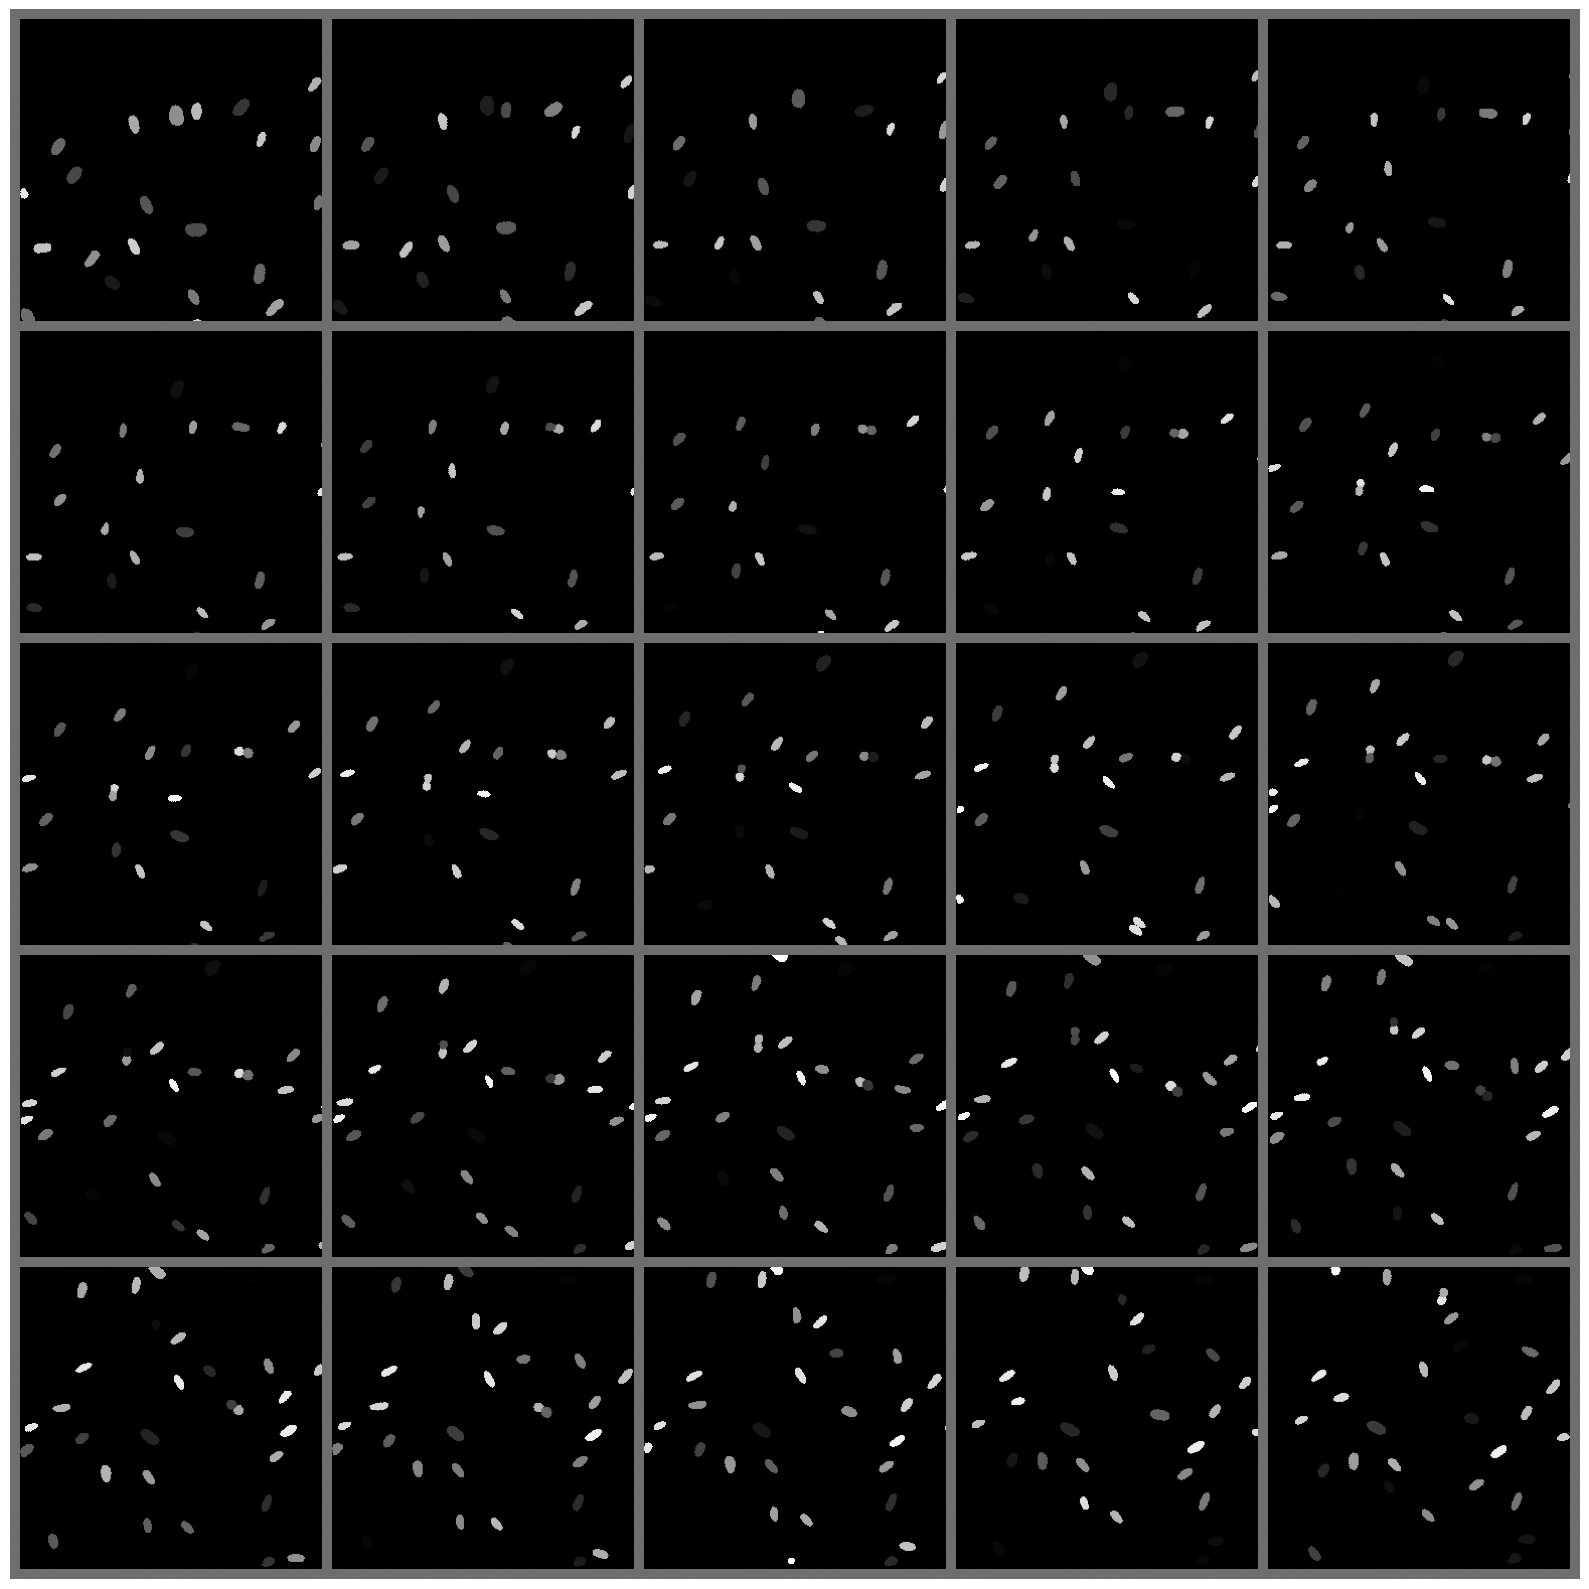

In [22]:

# control_images_small = resize(
#     control_segments_data,
#     (
#         control_segments_data.shape[0],
#         control_segments_data.shape[1] // 4,
#         control_segments_data.shape[2] // 4,
#     ),
#     preserve_range=True,
#     anti_aliasing=True,
# )

# Full montage
seq = montage(
    control_segments_data[:25, :300, :300],
    grid_shape=(5, 5),
    padding_width=10,
    fill=255,
)


# seq = montage(
#     control_images_small,
#     grid_shape=(9, 8),
#     padding_width=5,
#     fill=control_images_small.max(),
# )

fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(seq, cmap="gray")
ax.axis("off")
plt.tight_layout()
plt.show()

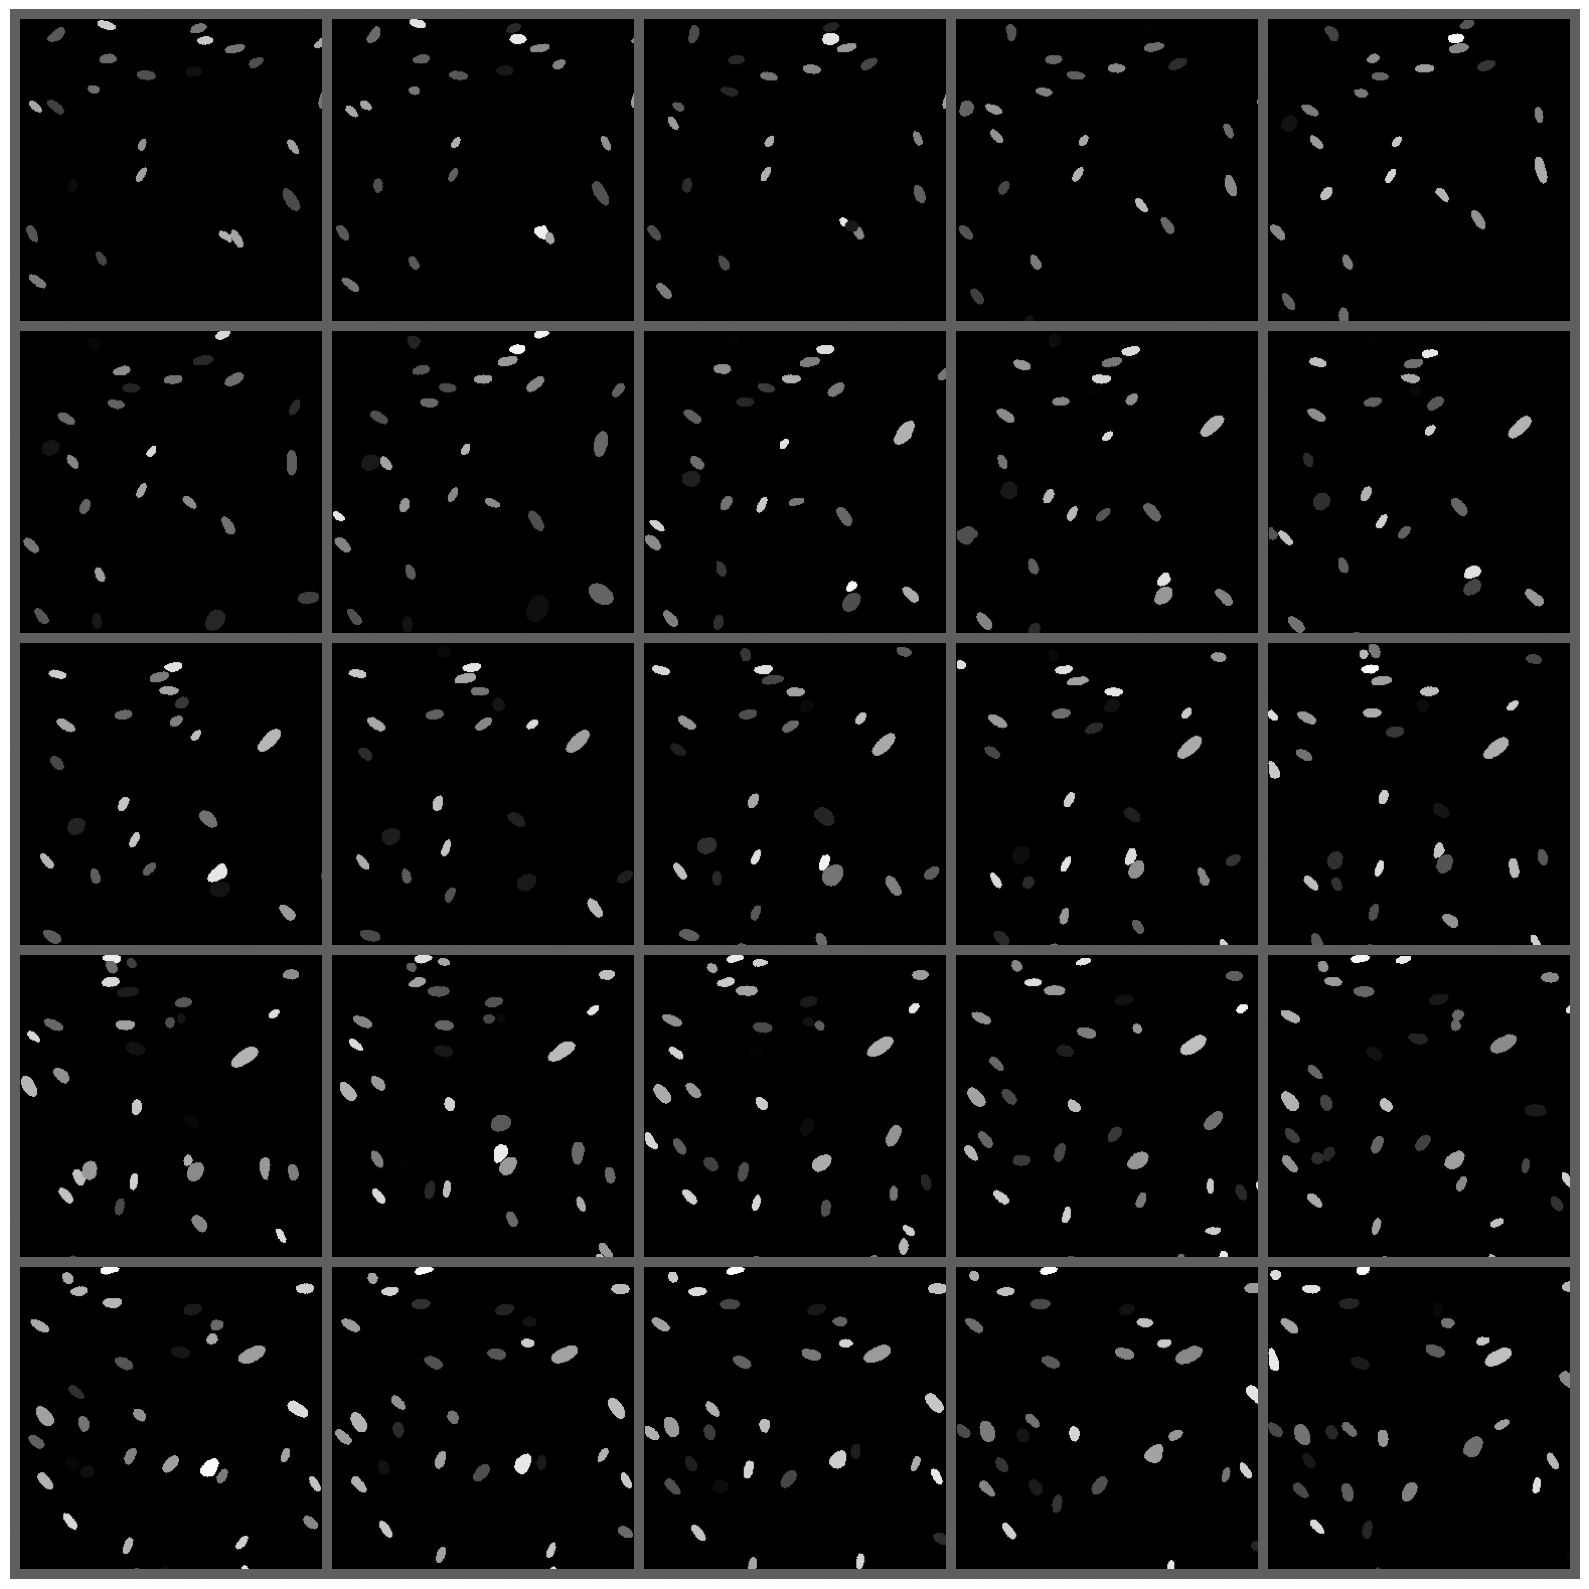

In [23]:
from skimage.transform import resize

# hyb_images_small = resize(
#     hyb_segments_data,
#     (
#         hyb_segments_data.shape[0],
#         hyb_segments_data.shape[1] // 4,
#         hyb_segments_data.shape[2] // 4,
#     ),
#     preserve_range=True,
#     anti_aliasing=True,
# )

# Full montage
seq = montage(
    hyb_segments_data[:25, :300, :300],
    grid_shape=(5, 5),
    padding_width=10,
    fill=255,
)


# seq = montage(
#     hyb_images_small,
#     grid_shape=(9, 8),
#     padding_width=5,
#     fill=hyb_images_small.max(),
# )

fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(seq, cmap="gray")
ax.axis("off")
plt.tight_layout()
plt.show()

# btrack

In [7]:
%%time

FEATURES = [
    "area", 
    "axis_major_length",#"major_axis_length", 
    "axis_minor_length",#"minor_axis_length", 
    "orientation", 
    "solidity",
    "eccentricity"
]



control_objects1 = btrack.utils.segmentation_to_objects(
    control_segments_data1, 
    properties=tuple(FEATURES), 
    num_workers=8,  # parallelise this
)

control_objects2 = btrack.utils.segmentation_to_objects(
    control_segments_data2, 
    properties=tuple(FEATURES), 
    num_workers=8,  # parallelise this
)

print('Finishing building track objects.')

# hyb_objects = btrack.utils.segmentation_to_objects(
#     hyb_segments_data, 
#     properties=tuple(FEATURES), 
#     num_workers=16,  # parallelise this
# )

[INFO][2026/07/24 10:01:51 AM] Localizing objects from segmentation...
[INFO][2026/07/24 10:01:51 AM] Processing using 8 workers.
100%|██████████| 67/67 [00:08<00:00,  8.00it/s]
[INFO][2026/07/24 10:02:00 AM] Objects are of type: <class 'dict'>
[INFO][2026/07/24 10:02:00 AM] ...Found 39967 objects in 67 frames.
[INFO][2026/07/24 10:02:00 AM] Localizing objects from segmentation...
[INFO][2026/07/24 10:02:00 AM] Processing using 8 workers.
100%|██████████| 137/137 [00:15<00:00,  8.79it/s]
[INFO][2026/07/24 10:02:17 AM] Objects are of type: <class 'dict'>
[INFO][2026/07/24 10:02:18 AM] ...Found 94187 objects in 137 frames.


Finishing building track objects.
CPU times: user 6.63 s, sys: 9.45 s, total: 16.1 s
Wall time: 27.4 s


In [6]:
def isolate_failure_stage(objects, config_path, max_search_radius, volume):
    """
    Runs btrack twice: once with just track() (motion-model-only linking),
    once adding optimize() (hypothesis-model global reassembly). Compare
    track length distributions between the two runs.
 
    If track()-only already gives near-singleton tracks -> the motion model
    (search radius / dt / P,R,Q / max_lost) is the problem.
    If track()-only gives reasonable tracklets but they collapse after
    optimize() -> the hypothesis model config is the problem.
    """
    def _run(use_optimize):
        with btrack.BayesianTracker() as tracker:
            tracker.configure(config_path)
            tracker.max_search_radius = max_search_radius
            tracker.append(objects)
            tracker.volume = volume
            tracker.track()
            if use_optimize:
                tracker.optimize()
            return [len(t) for t in tracker.tracks]
 
    lengths_no_opt = _run(use_optimize=False)
    lengths_opt = _run(use_optimize=True)
 
    def summarize(name, lengths):
        lengths = np.array(lengths)
        print(f"{name}: n_tracks={len(lengths)}  mean_len={lengths.mean():.2f}  "
              f"median_len={np.median(lengths):.1f}  "
              f"frac_len1={(lengths == 1).mean():.2%}")
 
    summarize("track() only (motion model)", lengths_no_opt)
    summarize("track() + optimize() (hypothesis model)", lengths_opt)
    
isolate_failure_stage(control_objects1, CONFIG_FILE, 30, ((0, 1600), (0, 1200)))

[INFO][2026/07/24 09:36:28 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 09:36:28 AM] Starting BayesianTracker session
[INFO][2026/07/24 09:36:28 AM] Loading configuration file: cell_config.json
[INFO][2026/07/24 09:36:28 AM] Objects are of type: <class 'list'>
[INFO][2026/07/24 09:36:28 AM] Starting tracking... 
[INFO][2026/07/24 09:36:28 AM] Update using: ['MOTION']
[INFO][2026/07/24 09:36:28 AM] Tracking objects in frames 0 to 67 (of 67)...
[INFO][2026/07/24 09:36:34 AM]  - Timing (Bayesian updates: 91.63ms, Linking: 3.78ms)
[INFO][2026/07/24 09:36:34 AM]  - Probabilities (Link: 1.00000, Lost: 0.73430)
[INFO][2026/07/24 09:36:34 AM] SUCCESS.
[INFO][2026/07/24 09:36:34 AM]  - Found 24769 tracks in 67 frames (in 0.0s)
[INFO][2026/07/24 09:36:34 AM]  - Inserted 60 dummy objects to fill tracking gaps
[INFO][2026/07/24 09:36:35 AM] Ending BayesianTracker session
[INFO][2026/07/24 09:36:35 

GLPK Integer Optimizer, v4.65
99076 rows, 280723 columns, 638364 non-zeros
280723 integer variables, all of which are binary
Preprocessing...
49538 rows, 280723 columns, 638364 non-zeros
280723 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 49538
Solving LP relaxation...
GLPK Simplex Optimizer, v4.65
49538 rows, 280723 columns, 638364 non-zeros
*     0: obj =  -1.172276077e+07 inf =   0.000e+00 (364)
*   340: obj =  -1.172500009e+07 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
Long-step dual simplex will be used
+   340: mip =     not found yet >=              -inf        (1; 0)
+   345: >>>>>  -1.172499794e+07 >=  -1.172499794e+07   0.0% (4; 0)
+   345: mip =  -1.172499794e+07 >=     tree is empty   0.0% (0; 7)
INTEGER OPTIMAL SOLUTION FOUND


[INFO][2026/07/24 09:37:35 AM]  - Fates.FALSE_POSITIVE: 139 (of 24769)
[INFO][2026/07/24 09:37:35 AM]  - Fates.LINK: 83 (of 79960)
[INFO][2026/07/24 09:37:35 AM]  - Fates.DIVIDE: 10 (of 126456)
[INFO][2026/07/24 09:37:35 AM]  - Fates.INITIALIZE_BORDER: 24255 (of 24267)
[INFO][2026/07/24 09:37:35 AM]  - Fates.INITIALIZE_FRONT: 231 (of 254)
[INFO][2026/07/24 09:37:35 AM]  - Fates.INITIALIZE_LAZY: 41 (of 248)
[INFO][2026/07/24 09:37:35 AM]  - Fates.TERMINATE_BORDER: 24245 (of 24255)
[INFO][2026/07/24 09:37:35 AM]  - Fates.TERMINATE_BACK: 246 (of 264)
[INFO][2026/07/24 09:37:35 AM]  - Fates.TERMINATE_LAZY: 46 (of 250)
[INFO][2026/07/24 09:37:35 AM]  - TOTAL: 280723 hypotheses
[INFO][2026/07/24 09:37:35 AM] Completed optimization with 24686 tracks
[INFO][2026/07/24 09:37:36 AM] Ending BayesianTracker session


track() only (motion model): n_tracks=24769  mean_len=1.62  median_len=1.0  frac_len1=98.26%
track() + optimize() (hypothesis model): n_tracks=24686  mean_len=1.62  median_len=1.0  frac_len1=98.51%


In [7]:
def inspect_feature_scales(objects, features):
    """
    Prints range/mean/std/NaN-count for each feature used in VISUAL
    tracking updates. Wildly different scales (e.g. area in the
    hundreds/thousands vs orientation in -pi..pi) will make the
    appearance-distance calculation dominated by whichever feature has
    the largest raw magnitude -- this can silently crush real matches
    even when position/motion agree well.
    """
    arr = {f: np.array([getattr(o, f) for o in objects], dtype=float)
           for f in features}
 
    print(f"{'feature':<20}{'min':>10}{'max':>10}{'mean':>10}{'std':>10}{'n_nan':>8}")
    for f, vals in arr.items():
        n_nan = np.isnan(vals).sum()
        v = vals[~np.isnan(vals)]
        print(f"{f:<20}{v.min():>10.2f}{v.max():>10.2f}{v.mean():>10.2f}"
              f"{v.std():>10.2f}{n_nan:>8d}")
 
    print("\nIf std/range varies by orders of magnitude across features "
          "(very likely here: area vs orientation/solidity/eccentricity), "
          "the appearance-distance metric is almost certainly dominated by "
          "the largest-magnitude feature (usually area). Consider z-scoring "
          "each feature before passing to btrack, or dropping VISUAL updates "
          "and using MOTION only until that's confirmed to fix things.")
    
inspect_feature_scales(control_objects1, FEATURES)

AttributeError: 'PyTrackObject' object has no attribute 'area'

In [8]:
def isolate_failure_stage(objects, config_path, max_search_radius, volume,
                           tracking_updates=("MOTION",), features=None):
    """
    Runs btrack twice: once with just track() (motion-model-only linking),
    once adding optimize() (hypothesis-model global reassembly). Compare
    track length distributions between the two runs.
 
    tracking_updates / features let you match your real pipeline
    (e.g. ("MOTION", "VISUAL") with your FEATURES list) so this is a
    true apples-to-apples test rather than a simplified one.
 
    If track()-only already gives near-singleton tracks -> the motion model
    (search radius / dt / P,R,Q / max_lost) -- OR the VISUAL feature
    matching, if enabled -- is the problem.
    If track()-only gives reasonable tracklets but they collapse after
    optimize() -> the hypothesis model config is the problem.
    """
    def _run(use_optimize):
        with btrack.BayesianTracker() as tracker:
            tracker.configure(config_path)
            tracker.max_search_radius = max_search_radius
            tracker.tracking_updates = list(tracking_updates)
            if features:
                tracker.features = features
            tracker.append(objects)
            tracker.volume = volume
            tracker.track()
            if use_optimize:
                tracker.optimize()
            return [len(t) for t in tracker.tracks]
 
    lengths_no_opt = _run(use_optimize=False)
    lengths_opt = _run(use_optimize=True)
 
    def summarize(name, lengths):
        lengths = np.array(lengths)
        print(f"{name}: n_tracks={len(lengths)}  mean_len={lengths.mean():.2f}  "
              f"median_len={np.median(lengths):.1f}  "
              f"frac_len1={(lengths == 1).mean():.2%}")
 
    summarize("track() only (motion model)", lengths_no_opt)
    summarize("track() + optimize() (hypothesis model)", lengths_opt)
 

print("MOTION only:")
isolate_failure_stage(control_objects1, CONFIG_FILE, 30, ((0, 1600), (0, 1200)),
                       tracking_updates=("MOTION",))

print("MOTION + VISUAL:")
isolate_failure_stage(control_objects1, CONFIG_FILE, 30, ((0, 1600), (0, 1200)),
                       tracking_updates=("MOTION", "VISUAL"), features=FEATURES)

[INFO][2026/07/24 09:45:18 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 09:45:18 AM] Starting BayesianTracker session
[INFO][2026/07/24 09:45:18 AM] Loading configuration file: cell_config.json
[INFO][2026/07/24 09:45:18 AM] Objects are of type: <class 'list'>
[INFO][2026/07/24 09:45:18 AM] Starting tracking... 
[INFO][2026/07/24 09:45:18 AM] Update using: ['MOTION']
[INFO][2026/07/24 09:45:19 AM] Tracking objects in frames 0 to 67 (of 67)...


MOTION only:


[INFO][2026/07/24 09:45:25 AM]  - Timing (Bayesian updates: 91.42ms, Linking: 1.79ms)
[INFO][2026/07/24 09:45:25 AM]  - Probabilities (Link: 1.00000, Lost: 0.73430)
[INFO][2026/07/24 09:45:25 AM] SUCCESS.
[INFO][2026/07/24 09:45:25 AM]  - Found 24769 tracks in 67 frames (in 0.0s)
[INFO][2026/07/24 09:45:25 AM]  - Inserted 60 dummy objects to fill tracking gaps
[INFO][2026/07/24 09:45:25 AM] Ending BayesianTracker session
[INFO][2026/07/24 09:45:25 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 09:45:25 AM] Starting BayesianTracker session
[INFO][2026/07/24 09:45:25 AM] Loading configuration file: cell_config.json
[INFO][2026/07/24 09:45:25 AM] Objects are of type: <class 'list'>
[INFO][2026/07/24 09:45:25 AM] Starting tracking... 
[INFO][2026/07/24 09:45:25 AM] Update using: ['MOTION']
[INFO][2026/07/24 09:45:25 AM] Tracking objects in frames 0 to 67 (of 67)...
[INFO][2026/07/24 09:45:31 

GLPK Integer Optimizer, v4.65
99076 rows, 280723 columns, 638364 non-zeros
280723 integer variables, all of which are binary
Preprocessing...
49538 rows, 280723 columns, 638364 non-zeros
280723 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 49538
Solving LP relaxation...
GLPK Simplex Optimizer, v4.65
49538 rows, 280723 columns, 638364 non-zeros
*     0: obj =  -1.172276077e+07 inf =   0.000e+00 (364)
*   340: obj =  -1.172500009e+07 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
Long-step dual simplex will be used
+   340: mip =     not found yet >=              -inf        (1; 0)
+   345: >>>>>  -1.172499794e+07 >=  -1.172499794e+07   0.0% (4; 0)
+   345: mip =  -1.172499794e+07 >=     tree is empty   0.0% (0; 7)
INTEGER OPTIMAL SOLUTION FOUND


[INFO][2026/07/24 09:46:26 AM]  - Fates.FALSE_POSITIVE: 139 (of 24769)
[INFO][2026/07/24 09:46:26 AM]  - Fates.LINK: 83 (of 79960)
[INFO][2026/07/24 09:46:26 AM]  - Fates.DIVIDE: 10 (of 126456)
[INFO][2026/07/24 09:46:26 AM]  - Fates.INITIALIZE_BORDER: 24255 (of 24267)
[INFO][2026/07/24 09:46:26 AM]  - Fates.INITIALIZE_FRONT: 231 (of 254)
[INFO][2026/07/24 09:46:26 AM]  - Fates.INITIALIZE_LAZY: 41 (of 248)
[INFO][2026/07/24 09:46:26 AM]  - Fates.TERMINATE_BORDER: 24245 (of 24255)
[INFO][2026/07/24 09:46:26 AM]  - Fates.TERMINATE_BACK: 246 (of 264)
[INFO][2026/07/24 09:46:26 AM]  - Fates.TERMINATE_LAZY: 46 (of 250)
[INFO][2026/07/24 09:46:26 AM]  - TOTAL: 280723 hypotheses
[INFO][2026/07/24 09:46:26 AM] Completed optimization with 24686 tracks
[INFO][2026/07/24 09:46:26 AM] Ending BayesianTracker session
[INFO][2026/07/24 09:46:26 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 09:46:26 AM]

track() only (motion model): n_tracks=24769  mean_len=1.62  median_len=1.0  frac_len1=98.26%
track() + optimize() (hypothesis model): n_tracks=24686  mean_len=1.62  median_len=1.0  frac_len1=98.51%
MOTION + VISUAL:


[INFO][2026/07/24 09:46:27 AM] Starting tracking... 
[INFO][2026/07/24 09:46:27 AM] Update using: ['MOTION', 'VISUAL']
[INFO][2026/07/24 09:46:27 AM] Tracking objects in frames 0 to 67 (of 67)...
[INFO][2026/07/24 09:46:37 AM]  - Timing (Bayesian updates: 55.17ms, Linking: 1.96ms)
[INFO][2026/07/24 09:46:37 AM]  - Probabilities (Link: 1.00000, Lost: 1.00000)
[INFO][2026/07/24 09:46:37 AM] SUCCESS.
[INFO][2026/07/24 09:46:37 AM]  - Found 24629 tracks in 67 frames (in 0.0s)
[INFO][2026/07/24 09:46:37 AM]  - Inserted 195 dummy objects to fill tracking gaps
[INFO][2026/07/24 09:46:37 AM] Ending BayesianTracker session
[INFO][2026/07/24 09:46:37 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 09:46:37 AM] Starting BayesianTracker session
[INFO][2026/07/24 09:46:37 AM] Loading configuration file: cell_config.json
[INFO][2026/07/24 09:46:37 AM] Objects are of type: <class 'list'>
[INFO][2026/07/2

GLPK Integer Optimizer, v4.65
98516 rows, 279936 columns, 636874 non-zeros
279936 integer variables, all of which are binary
Preprocessing...
49258 rows, 279936 columns, 636874 non-zeros
279936 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 49258
Solving LP relaxation...
GLPK Simplex Optimizer, v4.65
49258 rows, 279936 columns, 636874 non-zeros
*     0: obj =  -1.172271282e+07 inf =   0.000e+00 (139)
*   138: obj =  -1.172365547e+07 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
Long-step dual simplex will be used
+   138: mip =     not found yet >=              -inf        (1; 0)
+   138: >>>>>  -1.172365547e+07 >=  -1.172365547e+07   0.0% (1; 0)
+   138: mip =  -1.172365547e+07 >=     tree is empty   0.0% (0; 1)
INTEGER OPTIMAL SOLUTION FOUND


[INFO][2026/07/24 09:47:40 AM]  - Fates.DIVIDE: 1 (of 126260)
[INFO][2026/07/24 09:47:40 AM]  - Fates.INITIALIZE_BORDER: 24248 (of 24253)
[INFO][2026/07/24 09:47:40 AM]  - Fates.INITIALIZE_FRONT: 232 (of 257)
[INFO][2026/07/24 09:47:40 AM]  - Fates.INITIALIZE_LAZY: 36 (of 119)
[INFO][2026/07/24 09:47:40 AM]  - Fates.TERMINATE_BORDER: 24239 (of 24244)
[INFO][2026/07/24 09:47:40 AM]  - Fates.TERMINATE_BACK: 242 (of 251)
[INFO][2026/07/24 09:47:40 AM]  - Fates.TERMINATE_LAZY: 36 (of 134)
[INFO][2026/07/24 09:47:40 AM]  - TOTAL: 279936 hypotheses
[INFO][2026/07/24 09:47:40 AM] Completed optimization with 24604 tracks
[INFO][2026/07/24 09:47:41 AM] Ending BayesianTracker session


track() only (motion model): n_tracks=24629  mean_len=1.63  median_len=1.0  frac_len1=98.56%
track() + optimize() (hypothesis model): n_tracks=24604  mean_len=1.63  median_len=1.0  frac_len1=98.63%


In [ ]:
def motion_model_ablation(objects, base_config_path, volume,
                           tracking_updates=("MOTION",)):
    """
    Now that the Hungarian sanity check has ruled out data density as the
    cause, sweep the numeric MotionModel parameters one at a time against
    your REAL objects to find which one is gating out valid links.
    Baseline = your current config, unmodified.
    """
    with open(base_config_path) as f:
        base_cfg = json.load(f)
 
    def _run(cfg):
        tmp_path = "/tmp/_ablation_cfg.json"
        with open(tmp_path, "w") as f:
            json.dump(cfg, f)
        with btrack.BayesianTracker() as tracker:
            tracker.configure(tmp_path)
            tracker.tracking_updates = list(tracking_updates)
            tracker.append(objects)
            tracker.volume = volume
            tracker.track()
            lengths = np.array([len(t) for t in tracker.tracks])
        return lengths
 
    def summarize(name, lengths):
        print(f"{name:<45} n_tracks={len(lengths):<8} mean_len={lengths.mean():<8.2f} "
              f"median_len={np.median(lengths):<6.1f} frac_len1={(lengths==1).mean():.2%}")
 
    import copy
 
    print("Baseline (your current config):")
    summarize("  baseline", _run(base_cfg))
    print()
 
    # accuracy sweep
    print("accuracy sweep:")
    for acc in [1.0, 2.0, 7.5, 15.0, 30.0, 50.0]:
        cfg = copy.deepcopy(base_cfg)
        cfg["TrackerConfig"]["MotionModel"]["accuracy"] = acc
        summarize(f"  accuracy={acc}", _run(cfg))
    print()
 
    # dt sweep
    print("dt sweep:")
    for dt in [0.1, 0.5, 1.0, 2.0, 5.0]:
        cfg = copy.deepcopy(base_cfg)
        cfg["TrackerConfig"]["MotionModel"]["dt"] = dt
        summarize(f"  dt={dt}", _run(cfg))
    print()
 
    # G sigma sweep (process noise magnitude)
    print("G sigma sweep:")
    for g_sigma in [5.0, 15.0, 50.0, 150.0, 500.0]:
        cfg = copy.deepcopy(base_cfg)
        cfg["TrackerConfig"]["MotionModel"]["G"]["sigma"] = g_sigma
        summarize(f"  G.sigma={g_sigma}", _run(cfg))
    print()
 
    # P sigma sweep (initial uncertainty)
    print("P sigma sweep:")
    for p_sigma in [15.0, 150.0, 1500.0, 15000.0]:
        cfg = copy.deepcopy(base_cfg)
        cfg["TrackerConfig"]["MotionModel"]["P"]["sigma"] = p_sigma
        summarize(f"  P.sigma={p_sigma}", _run(cfg))
    print()
 
    # max_lost sweep
    print("max_lost sweep:")
    for ml in [2, 5, 10, 20]:
        cfg = copy.deepcopy(base_cfg)
        cfg["TrackerConfig"]["MotionModel"]["max_lost"] = ml
        summarize(f"  max_lost={ml}", _run(cfg))
        
        
motion_model_ablation(control_objects1, CONFIG_FILE, ((0, 1600), (0, 1200)))

[INFO][2026/07/24 10:02:18 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 10:02:18 AM] Starting BayesianTracker session
[INFO][2026/07/24 10:02:18 AM] Loading configuration file: /tmp/_ablation_cfg.json
[INFO][2026/07/24 10:02:18 AM] Objects are of type: <class 'list'>
[INFO][2026/07/24 10:02:18 AM] Starting tracking... 
[INFO][2026/07/24 10:02:18 AM] Update using: ['MOTION']
[INFO][2026/07/24 10:02:18 AM] Tracking objects in frames 0 to 67 (of 67)...


Baseline (your current config):


[INFO][2026/07/24 10:02:24 AM]  - Timing (Bayesian updates: 91.39ms, Linking: 1.97ms)
[INFO][2026/07/24 10:02:24 AM]  - Probabilities (Link: 1.00000, Lost: 0.73430)
[INFO][2026/07/24 10:02:24 AM] SUCCESS.
[INFO][2026/07/24 10:02:24 AM]  - Found 24769 tracks in 67 frames (in 0.0s)
[INFO][2026/07/24 10:02:24 AM]  - Inserted 60 dummy objects to fill tracking gaps
[INFO][2026/07/24 10:02:25 AM] Ending BayesianTracker session
[INFO][2026/07/24 10:02:25 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 10:02:25 AM] Starting BayesianTracker session
[INFO][2026/07/24 10:02:25 AM] Loading configuration file: /tmp/_ablation_cfg.json
[INFO][2026/07/24 10:02:25 AM] Objects are of type: <class 'list'>
[INFO][2026/07/24 10:02:25 AM] Starting tracking... 
[INFO][2026/07/24 10:02:25 AM] Update using: ['MOTION']
[INFO][2026/07/24 10:02:25 AM] Tracking objects in frames 0 to 67 (of 67)...


  baseline                                    n_tracks=24769    mean_len=1.62     median_len=1.0    frac_len1=98.26%

accuracy sweep:


[INFO][2026/07/24 10:02:57 AM]  - Timing (Bayesian updates: 500.53ms, Linking: 6.30ms)
[INFO][2026/07/24 10:02:57 AM]  - Probabilities (Link: 0.00000, Lost: 0.70107)
[INFO][2026/07/24 10:02:57 AM] SUCCESS.
[INFO][2026/07/24 10:02:57 AM]  - Found 39967 tracks in 67 frames (in 0.0s)
[INFO][2026/07/24 10:02:58 AM]  - Inserted 0 dummy objects to fill tracking gaps
[INFO][2026/07/24 10:02:58 AM] Ending BayesianTracker session
[INFO][2026/07/24 10:02:58 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 10:02:58 AM] Starting BayesianTracker session
[INFO][2026/07/24 10:02:58 AM] Loading configuration file: /tmp/_ablation_cfg.json
[INFO][2026/07/24 10:02:58 AM] Objects are of type: <class 'list'>
[INFO][2026/07/24 10:02:58 AM] Starting tracking... 
[INFO][2026/07/24 10:02:58 AM] Update using: ['MOTION']
[INFO][2026/07/24 10:02:59 AM] Tracking objects in frames 0 to 67 (of 67)...


  accuracy=1.0                                n_tracks=39967    mean_len=1.00     median_len=1.0    frac_len1=100.00%


[INFO][2026/07/24 10:03:06 AM]  - Timing (Bayesian updates: 149.90ms, Linking: 2.63ms)
[INFO][2026/07/24 10:03:06 AM]  - Probabilities (Link: 0.96296, Lost: 0.93182)
[INFO][2026/07/24 10:03:06 AM] SUCCESS.
[INFO][2026/07/24 10:03:06 AM]  - Found 25841 tracks in 67 frames (in 0.0s)
[INFO][2026/07/24 10:03:06 AM]  - Inserted 0 dummy objects to fill tracking gaps
[INFO][2026/07/24 10:03:06 AM] Ending BayesianTracker session
[INFO][2026/07/24 10:03:07 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 10:03:07 AM] Starting BayesianTracker session
[INFO][2026/07/24 10:03:07 AM] Loading configuration file: /tmp/_ablation_cfg.json
[INFO][2026/07/24 10:03:07 AM] Objects are of type: <class 'list'>
[INFO][2026/07/24 10:03:07 AM] Starting tracking... 
[INFO][2026/07/24 10:03:07 AM] Update using: ['MOTION']
[INFO][2026/07/24 10:03:07 AM] Tracking objects in frames 0 to 67 (of 67)...


  accuracy=2.0                                n_tracks=25841    mean_len=1.55     median_len=1.0    frac_len1=96.92%


[INFO][2026/07/24 10:03:13 AM]  - Timing (Bayesian updates: 94.72ms, Linking: 2.04ms)
[INFO][2026/07/24 10:03:13 AM]  - Probabilities (Link: 1.00000, Lost: 0.73430)
[INFO][2026/07/24 10:03:13 AM] SUCCESS.
[INFO][2026/07/24 10:03:13 AM]  - Found 24769 tracks in 67 frames (in 0.0s)
[INFO][2026/07/24 10:03:13 AM]  - Inserted 60 dummy objects to fill tracking gaps
[INFO][2026/07/24 10:03:13 AM] Ending BayesianTracker session
[INFO][2026/07/24 10:03:13 AM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/24 10:03:13 AM] Starting BayesianTracker session
[INFO][2026/07/24 10:03:13 AM] Loading configuration file: /tmp/_ablation_cfg.json
[INFO][2026/07/24 10:03:13 AM] Objects are of type: <class 'list'>
[INFO][2026/07/24 10:03:13 AM] Starting tracking... 
[INFO][2026/07/24 10:03:13 AM] Update using: ['MOTION']


In [7]:
%%time

# Code directly from Btrack documentation

outpath = "/scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test"

# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 30 # 50
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(control_objects1)

    # set the tracking volume
    tracker.volume=((0, 1600), (0, 1200))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()
    
    # store the tracks
    tracks = tracker.tracks
    
    # store the configuration
    cfg = tracker.configuration


    # export the track data 
    # tracker.export(f"tracks/{control_name1}.h5", obj_type="obj_type_1")
    tracker.export(f"{outpath}/{control_name1}.h5", obj_type="obj_type_1")



[INFO][2026/07/16 12:24:16 PM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/16 12:24:16 PM] Starting BayesianTracker session
[INFO][2026/07/16 12:24:16 PM] Loading configuration file: cell_config.json
[INFO][2026/07/16 12:24:16 PM] Objects are of type: <class 'list'>
[INFO][2026/07/16 12:24:16 PM] Starting tracking... 
[INFO][2026/07/16 12:24:16 PM] Update using: ['VISUAL', 'MOTION']
[INFO][2026/07/16 12:24:16 PM] Tracking objects in frames 0 to 67 (of 67)...
[INFO][2026/07/16 12:24:26 PM]  - Timing (Bayesian updates: 54.48ms, Linking: 1.71ms)
[INFO][2026/07/16 12:24:26 PM]  - Probabilities (Link: 1.00000, Lost: 1.00000)
[INFO][2026/07/16 12:24:26 PM] SUCCESS.
[INFO][2026/07/16 12:24:26 PM]  - Found 24629 tracks in 67 frames (in 0.0s)
[INFO][2026/07/16 12:24:26 PM]  - Inserted 195 dummy objects to fill tracking gaps
[INFO][2026/07/16 12:24:26 PM] Loading hypothesis model: cell_hypothesis
[INFO

GLPK Integer Optimizer, v4.65
98516 rows, 279936 columns, 636874 non-zeros
279936 integer variables, all of which are binary
Preprocessing...
49258 rows, 279936 columns, 636874 non-zeros
279936 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 49258
Solving LP relaxation...
GLPK Simplex Optimizer, v4.65
49258 rows, 279936 columns, 636874 non-zeros
*     0: obj =  -1.172271282e+07 inf =   0.000e+00 (139)
*   138: obj =  -1.172365547e+07 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
Long-step dual simplex will be used
+   138: mip =     not found yet >=              -inf        (1; 0)
+   138: >>>>>  -1.172365547e+07 >=  -1.172365547e+07   0.0% (1; 0)
+   138: mip =  -1.172365547e+07 >=     tree is empty   0.0% (0; 1)
INTEGER OPTIMAL SOLUTION FOUND


[INFO][2026/07/16 12:25:19 PM]  - Fates.INITIALIZE_LAZY: 36 (of 119)
[INFO][2026/07/16 12:25:19 PM]  - Fates.TERMINATE_BORDER: 24239 (of 24244)
[INFO][2026/07/16 12:25:19 PM]  - Fates.TERMINATE_BACK: 242 (of 251)
[INFO][2026/07/16 12:25:19 PM]  - Fates.TERMINATE_LAZY: 36 (of 134)
[INFO][2026/07/16 12:25:19 PM]  - TOTAL: 279936 hypotheses
[INFO][2026/07/16 12:25:19 PM] Completed optimization with 24604 tracks
[INFO][2026/07/16 12:25:21 PM] Opening HDF file: /scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test/01_control_C2.h5...
[INFO][2026/07/16 12:25:22 PM] Writing tracks/obj_type_1
[WARNING][2026/07/16 12:25:22 PM] Removing tracks/obj_type_1.
[INFO][2026/07/16 12:25:22 PM] Writing dummies/obj_type_1
[INFO][2026/07/16 12:25:22 PM] Writing LBEP/obj_type_1
[INFO][2026/07/16 12:25:22 PM] Writing fates/obj_type_1
[INFO][2026/07/16 12:25:22 PM] Closing HDF file: /scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test/01_control_C2.h5
[INFO][2026/07/16 12:25:22 PM] Ending Bay

CPU times: user 1min 6s, sys: 414 ms, total: 1min 6s
Wall time: 1min 6s


In [8]:
%%time

# Code directly from Btrack documentation

outpath = "/scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test"

# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 30 # 50
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(control_objects2)

    # set the tracking volume
    tracker.volume=((0, 1600), (0, 1200))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()
    
    # store the tracks
    tracks = tracker.tracks
    
    # store the configuration
    cfg = tracker.configuration


    # export the track data 
    # tracker.export(f"tracks/{control_name1}.h5", obj_type="obj_type_1")
    tracker.export(f"{outpath}/{control_name2}.h5", obj_type="obj_type_1")



[INFO][2026/07/16 12:26:10 PM] Loaded btrack: /nfs/turbo/umms-indikar/Jillian/conda-envs/btrack-env/lib/python3.11/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/16 12:26:10 PM] Starting BayesianTracker session
[INFO][2026/07/16 12:26:10 PM] Loading configuration file: cell_config.json
[INFO][2026/07/16 12:26:10 PM] Objects are of type: <class 'list'>
[INFO][2026/07/16 12:26:11 PM] Starting tracking... 
[INFO][2026/07/16 12:26:11 PM] Update using: ['VISUAL', 'MOTION']
[INFO][2026/07/16 12:26:11 PM] Tracking objects in frames 0 to 99 (of 137)...
[INFO][2026/07/16 12:26:30 PM]  - Timing (Bayesian updates: 116.67ms, Linking: 3.08ms)
[INFO][2026/07/16 12:26:30 PM]  - Probabilities (Link: 1.00000, Lost: 1.00000)
[INFO][2026/07/16 12:26:30 PM]  - Stats (Active: 362, Lost: 409, Conflicts resolved: 2169)
[INFO][2026/07/16 12:26:30 PM] Tracking objects in frames 100 to 137 (of 137)...
[INFO][2026/07/16 12:26:44 PM]  - Timing (Bayesian updates: 196.28ms, Linking: 3.58ms)
[INFO][2026/07/1

GLPK Integer Optimizer, v4.65
224652 rows, 905841 columns, 2211826 non-zeros
905841 integer variables, all of which are binary
Preprocessing...
112326 rows, 905841 columns, 2211826 non-zeros
905841 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 112326
Solving LP relaxation...
GLPK Simplex Optimizer, v4.65
112326 rows, 905841 columns, 2211826 non-zeros
*     0: obj =  -2.771266352e+07 inf =   0.000e+00 (776)
*   747: obj =  -2.771776950e+07 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
Long-step dual simplex will be used
+   747: mip =     not found yet >=              -inf        (1; 0)
+   751: mip =     not found yet >=  -2.771776446e+07        (6; 0)
+   753: >>>>>  -2.771776238e+07 >=  -2.771776446e+07 < 0.1% (7; 0)
+   753: mip =  -2.771776238e+07 >=     tree is empty   0.0% (0; 13)

[INFO][2026/07/16 12:36:44 PM]  - Fates.FALSE_POSITIVE: 304 (of 56163)
[INFO][2026/07/16 12:36:44 PM]  - Fates.LINK: 201 (of 224882)
[INFO][2026/07/16 12:36:44 PM]  - Fates.DIVIDE: 22 (of 512470)
[INFO][2026/07/16 12:36:44 PM]  - Fates.INITIALIZE_BORDER: 55255 (of 55315)
[INFO][2026/07/16 12:36:44 PM]  - Fates.INITIALIZE_FRONT: 217 (of 226)
[INFO][2026/07/16 12:36:44 PM]  - Fates.INITIALIZE_LAZY: 142 (of 622)
[INFO][2026/07/16 12:36:44 PM]  - Fates.TERMINATE_BORDER: 55108 (of 55153)
[INFO][2026/07/16 12:36:44 PM]  - Fates.TERMINATE_BACK: 413 (of 434)
[INFO][2026/07/16 12:36:44 PM]  - Fates.TERMINATE_LAZY: 115 (of 576)
[INFO][2026/07/16 12:36:44 PM]  - TOTAL: 905841 hypotheses
[INFO][2026/07/16 12:36:44 PM] Completed optimization with 55962 tracks
[INFO][2026/07/16 12:36:49 PM] Opening HDF file: /scratch/indikar_root/indikar1/jrcwycy/HYB/btrack/tracks_test/02_control_C2.h5...
[INFO][2026/07/16 12:36:50 PM] Writing objects/obj_type_1
[INFO][2026/07/16 12:36:50 PM] Writing labels/obj_type

CPU times: user 10min 39s, sys: 2.4 s, total: 10min 41s
Wall time: 10min 44s


In [11]:
print(CONFIG_FILE)

cell_config.json


In [26]:


# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 50
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(control_objects)

    # set the tracking volume
    tracker.volume=((0, 1600), (0, 1200))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()
    
    # store the tracks
    tracks = tracker.tracks
    
    # store the configuration
    cfg = tracker.configuration


    # export the track data 
    tracker.export(f"tracks/{hybrid_name}.h5", obj_type="obj_type_1")



[INFO][2026/07/14 05:18:45 PM] Loaded btrack: /home/nuvi/.local/lib/python3.12/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/14 05:18:45 PM] Starting BayesianTracker session
[INFO][2026/07/14 05:18:45 PM] Loading configuration file: /home/nuvi/.cache/btrack-examples/examples/cell_config.json
[INFO][2026/07/14 05:18:45 PM] Objects are of type: <class 'list'>
[INFO][2026/07/14 05:18:46 PM] Starting tracking... 
[INFO][2026/07/14 05:18:46 PM] Update using: ['VISUAL', 'MOTION']
[INFO][2026/07/14 05:18:47 PM] Tracking objects in frames 0 to 99 (of 137)...
[INFO][2026/07/14 05:19:04 PM]  - Timing (Bayesian updates: 100.36ms, Linking: 2.66ms)
[INFO][2026/07/14 05:19:04 PM]  - Probabilities (Link: 0.99999, Lost: 0.99996)
[INFO][2026/07/14 05:19:04 PM]  - Stats (Active: 322, Lost: 644, Conflicts resolved: 2359)
[INFO][2026/07/14 05:19:04 PM] Tracking objects in frames 100 to 137 (of 137)...
[INFO][2026/07/14 05:19:15 PM]  - Timing (Bayesian updates: 145.11ms, Linking: 3.08ms)
[INFO][20

GLPK Integer Optimizer, v4.52
226964 rows, 510687 columns, 1094478 non-zeros
510687 integer variables, all of which are binary
Preprocessing...
113482 rows, 510687 columns, 1094478 non-zeros
510687 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 113482
Solving LP relaxation...
GLPK Simplex Optimizer, v4.52
113482 rows, 510687 columns, 1094478 non-zeros
*     0: obj =  -3.119021715e+07  infeas =  0.000e+00 (0)
*   500: obj =  -3.119492246e+07  infeas =  0.000e+00 (0)
*   761: obj =  -3.119562267e+07  infeas =  0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Integer optimization begins...
+   761: mip =     not found yet >=              -inf        (1; 0)
+   762: >>>>>  -3.119562267e+07 >=  -3.119562267e+07   0.0% (1; 0)
+   762: mip =  -3.119562267e+07 >=     tree is empty   0.0% (0; 1)
INTEGER OPTIMAL SOLUTION FOUND


[INFO][2026/07/14 05:21:54 PM]  - Fates.FALSE_POSITIVE: 216 (of 56741)
[INFO][2026/07/14 05:21:54 PM]  - Fates.LINK: 313 (of 153878)
[INFO][2026/07/14 05:21:54 PM]  - Fates.DIVIDE: 16 (of 186586)
[INFO][2026/07/14 05:21:54 PM]  - Fates.INITIALIZE_BORDER: 55789 (of 55837)
[INFO][2026/07/14 05:21:54 PM]  - Fates.INITIALIZE_FRONT: 207 (of 218)
[INFO][2026/07/14 05:21:54 PM]  - Fates.INITIALIZE_LAZY: 184 (of 686)
[INFO][2026/07/14 05:21:54 PM]  - Fates.TERMINATE_BORDER: 55690 (of 55731)
[INFO][2026/07/14 05:21:54 PM]  - Fates.TERMINATE_BACK: 352 (of 370)
[INFO][2026/07/14 05:21:54 PM]  - Fates.TERMINATE_LAZY: 154 (of 640)
[INFO][2026/07/14 05:21:54 PM]  - TOTAL: 510687 hypotheses
[INFO][2026/07/14 05:21:54 PM] Completed optimization with 56428 tracks
[INFO][2026/07/14 05:21:59 PM] Opening HDF file: tracks/02_hybrid_C3.h5...
[INFO][2026/07/14 05:22:00 PM] Writing objects/obj_type_1
[INFO][2026/07/14 05:22:00 PM] Writing labels/obj_type_1
[INFO][2026/07/14 05:22:00 PM] Loading objects/obj_ty

In [40]:

h5_path = "tracks/02_control_B2.h5"

with btrack.io.HDF5FileHandler(
    h5_path,
    "r",
    obj_type="obj_type_1",
) as reader:
    tracks = reader.tracks

print(f"Loaded {len(tracks)} tracks")

[INFO][2026/07/14 05:30:51 PM] Opening HDF file: tracks/02_control_B2.h5...
[INFO][2026/07/14 05:30:51 PM] Loading tracks/obj_type_1
[INFO][2026/07/14 05:30:51 PM] Loading LBEP/obj_type_1
[INFO][2026/07/14 05:30:51 PM] Loading objects/obj_type_1 (91039, 5) (91039 filtered: None)
[INFO][2026/07/14 05:30:52 PM] Closing HDF file: tracks/02_control_B2.h5


Loaded 56428 tracks


In [41]:


track_dfs = []

for track in tracks:
    track_df = pd.DataFrame(track.to_dict())
    track_dfs.append(track_df)

df = pd.concat(track_dfs, ignore_index=True)

df = df.sort_values(["ID", "t"]).reset_index(drop=True)

ID
509    137
504    137
498    137
496    137
495    137
493    137
492    137
487    137
484    137
483    137
dtype: int64

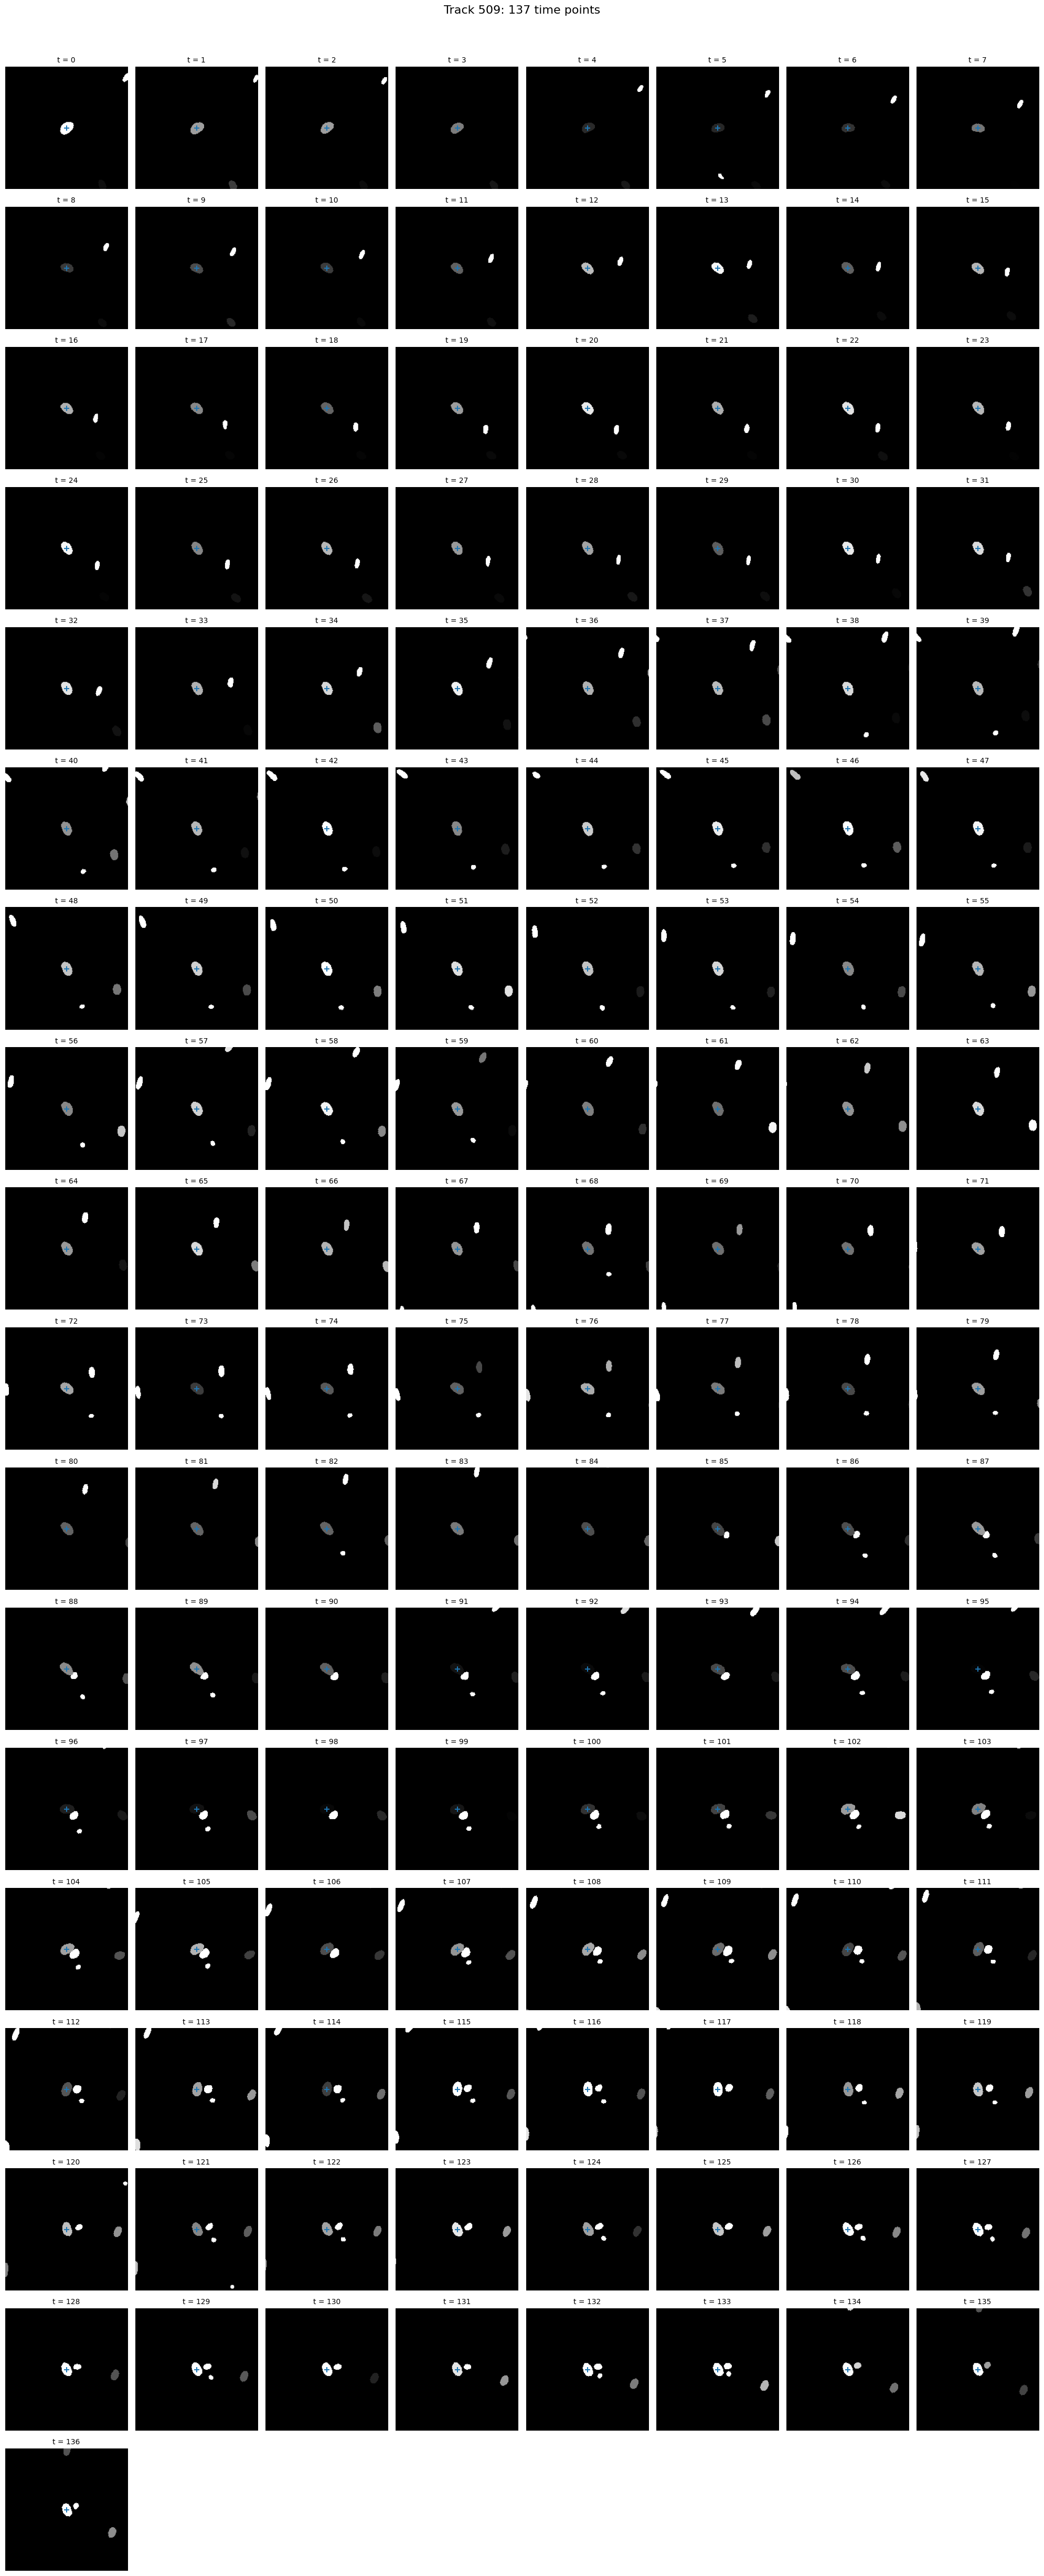

In [46]:
track_lengths = (
    df.groupby("ID")
    .size()
    .sort_values(ascending=False)
)

display(track_lengths.head(10))

track_id = track_lengths.index[0]

cell_crops, cell_trajectory = plot_track_montage(
    image_stack=control_segments_data,
    track_df=df,
    track_id=track_id,
    crop_size=200,
    ncols=8,
)

In [48]:


times = cell_trajectory["t"].to_numpy()

vmin, vmax = np.percentile(cell_crops, [1, 99.5])

fig, ax = plt.subplots(figsize=(6, 6))

image_artist = ax.imshow(
    cell_crops[0],
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

center = cell_crops.shape[1] / 2

center_artist = ax.scatter(
    center,
    center,
    marker="+",
    s=150,
    linewidths=2,
)

title_artist = ax.set_title(
    f"Track {track_id} | t = {times[0]}"
)

ax.axis("off")


def update(frame_index):
    image_artist.set_data(cell_crops[frame_index])
    title_artist.set_text(
        f"Track {track_id} | t = {times[frame_index]}"
    )

    return image_artist, center_artist, title_artist


animation = FuncAnimation(
    fig,
    update,
    frames=len(cell_crops),
    interval=300,   # milliseconds per frame
    blit=False,
    repeat=True,
)

plt.close(fig)

HTML(animation.to_jshtml())

In [6]:


def full_tracking_pipeline(name, segment_path):
    FEATURES = [
        "area", 
        "major_axis_length", 
        "minor_axis_length", 
        "orientation", 
        "solidity",
        "eccentricity"
    ]
    
    segments_data = np.load(segment_path)
    
    objects = btrack.utils.segmentation_to_objects(
        segments_data, 
        properties=tuple(FEATURES), 
        num_workers=16,  # parallelise this
    )
    # Code directly from Btrack documentation
    
    
    # initialise a tracker session using a context manager
    with btrack.BayesianTracker() as tracker:
    
        # configure the tracker using a config file
        tracker.configure(CONFIG_FILE)
        tracker.max_search_radius = 50
        tracker.tracking_updates = ["MOTION", "VISUAL"]
        tracker.features = FEATURES
    
        # append the objects to be tracked
        tracker.append(objects)
    
        # set the tracking volume
        tracker.volume=((0, 1600), (0, 1200))
    
        # track them (in interactive mode)
        tracker.track(step_size=100)
    
        # generate hypotheses and run the global optimizer
        tracker.optimize()
    
        # get the tracks in a format for napari visualization
        data, properties, graph = tracker.to_napari()
        
        # store the tracks
        tracks = tracker.tracks
        
        # store the configuration
        cfg = tracker.configuration
    
    
        # export the track data 
        tracker.export(f"tracks/{name}.h5", obj_type="obj_type_1")
    
    
    h5_path = f"tracks/{name}.h5"
    
    with btrack.io.HDF5FileHandler(
        h5_path,
        "r",
        obj_type="obj_type_1",
    ) as reader:
        tracks = reader.tracks
    
    print(f"Loaded {len(tracks)} tracks")
    
    
    track_dfs = []
    
    for track in tracks:
        track_df = pd.DataFrame(track.to_dict())
        track_dfs.append(track_df)
    
    df = pd.concat(track_dfs, ignore_index=True)
    
    df = df.sort_values(["ID", "t"]).reset_index(drop=True)
    
    
    track_lengths = (
        df.groupby("ID")
        .size()
        .sort_values(ascending=False)
    )
    
    display(track_lengths.head(10))
    
    track_id = track_lengths.index[0]
    
    cell_crops, cell_trajectory = plot_track_montage(
        image_stack=segments_data,
        track_df=df,
        track_id=track_id,
        crop_size=200,
        ncols=8,
    )
    
    times = cell_trajectory["t"].to_numpy()
    
    vmin, vmax = np.percentile(cell_crops, [1, 99.5])
    
    fig, ax = plt.subplots(figsize=(6, 6))
    

    
    image_artist = ax.imshow(
        cell_crops[0],
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )
    
    center = cell_crops.shape[1] / 2
    
    center_artist = ax.scatter(
        center,
        center,
        marker="+",
        s=150,
        linewidths=2,
    )
    
    title_artist = ax.set_title(
        f"Track {track_id} | t = {times[0]}"
    )
    
    ax.axis("off")
    
    def update(frame_index):
        image_artist.set_data(cell_crops[frame_index])
        title_artist.set_text(
            f"Track {track_id} | t = {times[frame_index]}"
        )
    
        return image_artist, center_artist, title_artist
    
    
    animation = FuncAnimation(
        fig,
        update,
        frames=len(cell_crops),
        interval=300,   # milliseconds per frame
        blit=False,
        repeat=True,
    )
    
    plt.close(fig)
    
    HTML(animation.to_jshtml())

In [ ]:


for i in range(len(full_segments_list)):
    name = segments_list[i]
    segment_path = full_segments_list[i]
    
    full_tracking_pipeline(name, segment_path)

[INFO][2026/07/14 10:15:33 PM] Localizing objects from segmentation...
[INFO][2026/07/14 10:15:33 PM] Processing using 16 workers.
100%|██████████| 137/137 [00:14<00:00,  9.49it/s]
[INFO][2026/07/14 10:15:48 PM] Objects are of type: <class 'dict'>
[INFO][2026/07/14 10:15:49 PM] ...Found 123894 objects in 137 frames.
[INFO][2026/07/14 10:15:49 PM] Loaded btrack: /home/nuvi/.local/lib/python3.12/site-packages/btrack/libs/libtracker.so
[INFO][2026/07/14 10:15:49 PM] Starting BayesianTracker session
[INFO][2026/07/14 10:15:49 PM] Loading configuration file: /home/nuvi/.cache/btrack-examples/examples/cell_config.json
[INFO][2026/07/14 10:15:49 PM] Objects are of type: <class 'list'>
[INFO][2026/07/14 10:15:51 PM] Starting tracking... 
[INFO][2026/07/14 10:15:51 PM] Update using: ['VISUAL', 'MOTION']
[INFO][2026/07/14 10:15:52 PM] Tracking objects in frames 0 to 99 (of 137)...
[INFO][2026/07/14 10:16:08 PM]  - Timing (Bayesian updates: 81.85ms, Linking: 3.05ms)
[INFO][2026/07/14 10:16:08 PM]